# Demand Forecasting & Inventory Optimization
<p align="center">
  <img src="image/logo.jpg" width="600"/>
</p>




# Amazon E-Commerce Purchase Data Analysis
### Demand Forecasting & Inventory Optimisation
 
---
 
## Part 1
 
---
 

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2. Load Dataset

In [8]:
df_raw = pd.read_csv("amazon-purchases.csv")

print(f"Dataset shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head()


Dataset shape : 1,048,575 rows × 8 columns
Memory usage  : 488.3 MB


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,12/4/2018,7.98,1,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,12/22/2018,13.99,1,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,12/24/2018,8.99,1,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,12/25/2018,10.45,1,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,12/25/2018,10.00,1,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [9]:
# Column overview
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1048575 non-null  object 
 1   Purchase Price Per Unit   1048575 non-null  float64
 2   Quantity                  1048575 non-null  int64  
 3   Shipping Address State    997480 non-null   object 
 4   Title                     997060 non-null   object 
 5   ASIN/ISBN (Product Code)  1047967 non-null  object 
 6   Category                  997766 non-null   object 
 7   Survey ResponseID         1048575 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 64.0+ MB


## 3. Data Cleaning



In [10]:
#no. of years in the dataset
df_raw["Order Date"] = pd.to_datetime(df_raw["Order Date"], errors="coerce")

print(df_raw["Order Date"].dt.year.nunique())
print(sorted(df_raw["Order Date"].dt.year.dropna().unique()))

7
[np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [11]:
df = df_raw.drop(columns=["Shipping Address State"], errors="ignore")


print("Columns removed successfully")

Columns removed successfully


In [12]:
df.head()

,Order Date,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


--------
## Handling Duplicates

In [13]:
before = len(df)

df = df.drop_duplicates(
    subset=[
        "Survey ResponseID",
        "ASIN/ISBN (Product Code)",
        "Title",
        "Order Date",
        "Quantity",
        "Purchase Price Per Unit"
    ]
).reset_index(drop=True)

removed = before - len(df)
print(f"True same-user duplicates removed : {removed:,}")
print(f"Rows remaining                    : {len(df):,}")
print(f"Full exact duplicates remaining   : {df.duplicated().sum()}")

True same-user duplicates removed : 6,854
Rows remaining                    : 1,041,721
Full exact duplicates remaining   : 0


In [14]:
df = df.drop_duplicates().reset_index(drop=True)

-------
## Handle Missing Data

In [15]:
df.isna().sum()

Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Title                       51340
ASIN/ISBN (Product Code)      599
Category                    50640
Survey ResponseID               0
dtype: int64

In [16]:
missing_pct = df["Category"].isna().mean() * 100
print(f"Missing Category: {missing_pct:.2f}%")

Missing Category: 4.86%


In [17]:
missing_pct = df["ASIN/ISBN (Product Code)"].isna().mean() * 100
print(f"Missing Category: {missing_pct:.2f}%")

Missing Category: 0.06%


In [18]:
missing_pct = df["Title"].isna().mean() * 100
print(f"Missing Category: {missing_pct:.2f}%")

Missing Category: 4.93%


In [19]:
df = df.dropna(subset=["ASIN/ISBN (Product Code)","Category","Title"])

In [20]:
df.isna().sum()

Order Date                  0
Purchase Price Per Unit     0
Quantity                    0
Title                       0
ASIN/ISBN (Product Code)    0
Category                    0
Survey ResponseID           0
dtype: int64

-------
## 3.1 Add Revenue Column

In [21]:
# add revenue
df["Revenue"] = df["Purchase Price Per Unit"] * df["Quantity"]

In [22]:
df.head()

,Order Date,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Revenue
0,2018-12-04,7.98,1,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,7.98
1,2018-12-22,13.99,1,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,13.99
3,2018-12-25,10.45,1,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,10.45
4,2018-12-25,10.00,1,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,10.00
5,2019-02-18,10.99,1,Micro USB Cable Android Charger - Syncwire [2-...,B01GFB2E9M,COMPUTER_PROCESSOR,R_01vNIayewjIIKMF,10.99


-------
## 3.4 Category Mapping

In [23]:

CATEGORY_MAP = {
    "Books & Media": [
        "ABIS_BOOK", "ABIS_DVD", "ABIS_MUSIC", "ABIS_EBOOKS", "ABIS_HOME",
        "BOOK", "BOOKS_1973_AND_LATER", "PAPERBACK", "PRINTED_MEDIA",
        "PRINTS_AND_POSTERS", "MAGAZINE", "MAGAZINES", "MAPS", "MUSIC",
        "MUSIC_POPULAR", "MUSIC_POPULAR_VINYL", "PHYSICAL_MOVIE",
        "PHYSICAL_TV_SERIES", "PHYSICAL_VIDEO_GAME_SOFTWARE",
        "DOWNLOADABLE_VIDEO_GAME", "DOWNLOADABLE_TV", "CONSOLE_VIDEO_GAMES",
        "SOFTWARE_GAMES", "ABIS_VIDEO_GAMES", "VIDEO_GAME_CONSOLE",
        "VIDEO_GAME_CONTROLLER", "VIDEO_GAME_ACCESSORIES",
        "VIDEO_DISC_PLAYER", "DVD_PLAYER_OR_RECORDER", "AUDIO_CD_PLAYER",
        "BOOK_DOCUMENT_STAND", "ENTERTAINMENT_MEMORABILIA", "PRINTED_PRODUCT",
        "TRADING_CARDS_FACTORY_SEALED", "TRADING_CARDS_MISC_TRADING_CARDS",
        "TRADING_CARDS_CARDS_SETS", "COLLECTIBLE_COINS", "PRELOADED_ELECTRONIC_GAME",
        "KINDLE_UNLIMITED_MEMBERSHIP", "ELECTRONIC_BOOK_READER",
        "BLANK_MEDIA", "MEDIA_STORAGE", "SOFTWARE", "MOBILE_APPLICATION",
        "SKILL_APPLICATION", "PROTECTED_COLLECTION"
    ],

    "Electronics & Accessories": [
        "FLASH_MEMORY", "WATCH_BAND", "MEMORY_CARD_READER", "MEMORY_READER", "RAM_MEMORY",
        "INTERNAL_MEMORY", "COMPUTER", "COMPUTER_PROCESSOR", "COMPUTER_ADD_ON",
        "COMPUTER_COMPONENT", "COMPUTER_CHASSIS", "COMPUTER_DRIVE_OR_STORAGE",
        "COMPUTER_INPUT_DEVICE", "PERSONAL_COMPUTER", "NOTEBOOK_COMPUTER",
        "TABLET_COMPUTER", "AMAZON_TABLET", "AMAZON_TABLET_ACCESSORY",
        "AMAZON_BOOK_READER", "AMAZON_BOOK_READER_ACCESSORY",
        "HEADPHONES", "INPUT_MOUSE", "INPUT_PEN", "MOUSE_PAD",
        "KEYBOARD_MOUSE_SET", "KEYBOARDS", "KEYBOARD_TRAY", "KEYCAP",
        "MONITOR", "SCREEN_PROTECTOR", "MICROPHONE", "SPEAKERS", "SOUND_CARD",
        "VIDEO_CARD", "MOTHERBOARD", "OPTICAL_DISC_DRIVE", "Electronics",
        "HARD_DRIVE_ENCLOSURE", "GAMING_EQUIPMENT_ENCLOSURE",
        "SINGLE_BOARD_COMPUTER", "BAR_CODE_READER", "MP3_PLAYER","Electronics",
        "DIGITAL_PICTURE_FRAME", "VIRTUAL_REALITY_HEADSET",
        "WEARABLE_COMPUTER", "DIGITAL_DEVICE_3", "DIGITAL_DEVICE_3_ACCESSORY",
        "REMOTE_CONTROL", "CELL_PHONE_GRIP", "CELLULAR_PHONE",
        "CELLULAR_PHONE_CASE", "CELL_PHONE_HOLSTER", "PHONE", "PHONE_ACCESSORY",
        "LANDLINE_PHONE", "PORTABLE_ELECTRONIC_DEVICE_STAND",
        "PORTABLE_ELECTRONIC_DEVICE_COVER", "PORTABLE_ELECTRONIC_DEVICE_MOUNT",
        "NETWORKING_ROUTER", "NETWORK_INTERFACE_CONTROLLER_ADAPTER",
        "MODEM", "ANTENNA", "AV_SIGNAL_SWITCH", "AV_RECEIVER",
        "STANDALONE_STREAMING_MEDIA_PLAYER", "STANDALONE_STREAMING",
        "INTEGRATED_STEREO_SYSTEM", "RADIO", "TWO_WAY_RADIO",
        "CAMCORDER", "CAMERA", "CAMERA_DIGITAL", "CAMERA_BAGS_AND_CASES",
        "CAMERA_LENSES", "CAMERA_LENS_FILTERS", "CAMERA_LENS_ACCESSORY",
        "CAMERA_CONTINUOUS_LIGHT", "CAMERA_STAGE_LIGHTING_MODIFIER",
        "CAMERA_SUPPORT", "CAMERA_TRIPOD", "CAMERA_FLASH",
        "CAMERA_ENCLOSURE", "CAMERA_POWER_SUPPLY", "CAMERA_PRIVACY_COVER",
        "CAMERA_FILM", "PHOTOGRAPHIC_FILM", "PHOTOGRAPHIC_LIGHTING",
        "PHOTOGRAPHIC_PAPER", "PHOTOGRAPHIC_STUDIO_ITEMS",
        "ONBOARD_CAMERA", "WEBCAM", "PROJECTION_SCREEN",
        "SECURITY_CAMERA", "SECURITY_ELECTRONICS", "SECURITY_SYSTEM",
        "SURVEILANCE_SYSTEMS", "SURVEILLANCE_RECORDER_SYSTEM",
        "MOTION_DETECTOR_DEVICE", "GAS_SMOKE_FIRE_ALARM","MECHANICAL_BELT", "ELECTROMECHANICAL_GAUGE",
        "CHARGING_ADAPTER", "POWER_BANK", "POWER_STRIP", "POWER_CORD",
        "POWER_CONVERTER", "POWER_INVERTER", "POWER_SUPPLY",
        "POWER_SUPPLIES_OR_PROTECTION", "UNINTERRUPTIBLE_POWER_SUPPLY",
        "MULTIPORT_HUB", "CABLE_OR_ADAPTER", "CABLE_ASSEMBLY", "CABLE",
        "CABLE_TIE", "ELECTRONIC_CABLE", "ELECTRONIC_ADAPTER",
        "ELECTRONIC_SWITCH", "ELECTRONIC_FINDER", "ELECTRONIC_SENSOR",
        "ELECTRONIC_CONTROLLER", "ELECTRONIC_COMPONENT","Electronics",
        "ELECTRONIC_COMPONENT_TERMINAL", "ELECTRONIC_COMPONENT_AMPLIFIER",
        "ELECTRONIC_SIGNAL_CONVERTER", "ELECTRONIC_DEVICE_COOLING_PAD",
        "ELECTRONIC_DEVICE_DOCKING_STATION", "ELECTRONIC_DEVICE_SKIN",
        "ELECTRONIC_DEVICE_FACEPLATE", "ELECTRONIC_WIRE", "WIRE",
        "BATTERY", "FUSE", "RELAY", "TRANSFORMER", "CAPACITOR",
        "RESISTOR", "FIXED_RESISTOR", "TRANSISTOR", "TERMINAL_BLOCK",
        "DIP_SWITCH", "PC_BOARD_RELAY", "PROTOTYPING_BOARD",
        "OPTOELECTRONIC_COMPONENT", "ACCELERATION_SENSOR",
        "ELECTRONIC_KNOB", "TV_TUNER_CARD", "TELEVISION",
        "FLAT_SCREEN_DISPLAY_MOUNT", "CONTROLLER", "GPS_OR_NAVIGATION_SYSTEM",
        "GPS_OR_NAVIGATION_ACCESSORY", "LOCATION_TRACKER", "VOICE_RECORDER",
        "SCANNER", "SATELLITE_RECEIVER", "AUDIO_OR_VIDEO",
        "AUDIO_POWER_AMPLIFIER", "AUDIO_MIDI_INTERFACE",
        "AUDIO_MIDI_CONTROLLER", "AUDIO_MIXING_CONSOLE", "PA_SYSTEM",
        "RECEIVER_OR_AMPLIFIER", "CAR_ELECTRONICS", "CAR_AUDIO_OR_THEATER",
        "CE_ACCESSORY", "CE_CARRYING_CASE_OR_BAG", "CONSUMER_ELECTRONICS",
        "FSN_DEVICES", "VDO_DEVICES", "INSTRUMENT_PARTS_AND_ACCESSORIES",
        "SOUND_AND_RECORDING_EQUIPMENT", "ELECTRIC_MOTOR", "TUNER","PUMP_SPRAYER","Guitars",
        "KARAOKE_MACHINE", "MULTIFUNCTION_DEVICE", "Electronics"
    ],

    "Clothing & Apparel": [
        "APPAREL", "APPAREL_BELT", "APPAREL_GLOVES", "BELTS",
        "SHIRT", "ORCA_SHIRT", "BLOUSE", "PANTS", "SHORTS", "SKIRT",
        "DRESS", "COAT", "SWEATER", "SWEATSHIRT", "BLAZER", "SUIT",
        "VEST", "TRACK_SUIT", "TUNIC", "SOCKS", "UNDERPANTS",
        "UNDERWEAR", "BRA", "BRA_UNDERWEAR_SET", "TIGHTS",
        "SWIMWEAR", "NIGHTGOWN_NIGHTSHIRT", "SLEEPWEAR", "PAJAMAS",
        "KURTA", "SAREE", "SALWAR_SUIT_SET", "CHOLI", "DUPATTA",
        "ETHNIC_WEAR", "LEOTARD", "ONE_PIECE_OUTFIT",
        "COORDINATED_OUTFIT", "COSTUME_OUTFIT", "COSTUME_HEADWEAR",
        "COSTUME_MASK", "CHILDRENS_COSTUME", "ADULT_COSTUME", "COSTUME",
        "SHOES", "BOOT", "SANDAL", "SLIPPER", "FOOTWEAR",
        "FOOTWEAR_CARE_KIT", "SHOE_INSERT", "SUNGLASSES",
        "CORRECTIVE_EYEGLASSES", "COSTUME_EYEWEAR",
        "BLUE_LIGHT_BLOCKING_EYEGLASSES", "EYEGLASS_FRAME", "EYEGLASS_CASE",
        "EYEWEAR", "EYEGLASS_REPAIR_KIT", "WATCH", "HAT", "SCARF",
        "NECKTIE", "SUSPENDER", "WAIST_PACK", "TOTE_BAG", "HANDBAG",
        "WALLET", "BACKPACK", "DUFFEL_BAG", "SUITCASE", "LUGGAGE",
        "BAG", "CARRIER_BAG_CASE", "CARRYING_CASE_OR_BAG",
        "COIN_PURSE_POUCH", "ACCESSORY", "GUILD_ACCESSORIES",
        "FASHIONOTHER", "FASHIONRING", "FASHIONEARRING",
        "MOISTURIZING_SOCK_GLOVE", "ROBE", "OUTERWEAR",
        "GARMENT_PROTECTOR_COVER", "MEDICAL_COMPRESSION_GARMENT",
        "ARM_SLEEVE", "LEG_SLEEVE", "WAIST_CINCHER",
        "APPENDAGE_WARMER", "BODYSTOCKING", "UNION_SUIT",
        "WIG", "HAIRBAND", "OVERALLS", "BUCKLE", "CORSET", "KIMONO",
        "MANNEQUIN_CLOTHING_FORM", "SASH", "GLOVES"
    ],

    "Health & Personal Care": [
        "HEALTH_PERSONAL_CARE", "MEDICATION", "TOPICALS", "TOPICAL_HAIR",
        "NICOTINE_REPLACEMENT", "PROFESSIONAL_HEALTHCARE",
        "CLINICAL_DIAGNOSTIC_TESTING_KIT", "CHEMICAL_TEST_STRIP",
        "MEDICAL_TEST_STRIP", "GLUCOSE_METER", "STETHOSCOPE",
        "THERMOMETER", "BLOOD_LANCET", "SYRINGE", "MEDICAL_DEVICE",
        "ORTHOPEDIC_BRACE", "BODY_POSITIONER", "WEIGH_SCALE",
        "MASSAGER", "MASSAGE_STICK", "MUSCLE_ROLLER", "KNEE_PAD",
        "SHIN_GUARD", "SAFETY_MASK", "SAFETY_MASK_STRAP_EXTENDER",
        "RESPIRATOR", "FACE_SHIELD", "SAFETY_SUPPLY", "SAFETY_HARNESS",
        "HAND_SANITIZER", "DISPOSABLE_INCONTINENCE_SURFACE_PROTECTOR",
        "INCONTINENCE_PROTECTOR", "MENSTRUAL_CUP", "TAMPON",
        "SANITARY_NAPKIN", "CONDOM", "ENEMA_DOUCHE",
        "BREAST_PUMP", "BREAST_PETAL", "NASAL_ASPIRATOR",
        "MOUTH_GUARD", "HEARING_AMPLIFIER", "THERAPEUTIC_THERMAL_COMPRESS",
        "FIRST_AID_KIT", "PERSONAL_PILL_DISPENSER", "PILL_CUTTER",
        "SLEEP_MASK", "ORAL_IRRIGATOR", "TOOTHBRUSH", "TOOTHBRUSH_HEAD",
        "TOOTHBRUSH_HOLDER", "TOOTH_CLEANING_AGENT", "TOOTH_WHITENER",
        "DENTAL_FLOSS", "MOUTHWASH", "CONTACT_LENS_CLEANER",
        "WOUND_DRESSING", "PERSONAL_FLOTATION_DEVICE", "DAILY_LIVING_AIDS",
        "MEDICAL_SCRUB_SET", "EARPLUG", "EARMUFF", "FOOT_SCRAPER",
        "ELECTRIC_HEATING_PAD", "HAND_STRENGTHENER", "WALKER",
        "SHARPS_DISPOSAL_CONTAINER", "LAB_SUPPLY", "LAB_CHEMICAL",
        "LAB_UTENSIL", "BATH_SAFETY_SEATING", "HUMIDITY_METER",
        "PIPET", "MICROSCOPES", "BISS"
    ],

    "Beauty & Grooming": [
        "BEAUTY", "GUILD_BEAUTY_GROOMING", "FRAGRANCE", "PERSONAL_FRAGRANCE",
        "BODY_LUBRICANT", "SEXUAL_STIMULATION_DEVICE", "SEXUAL_WELLNESS",
        "SHAMPOO", "CONDITIONER", "HAIR_CLEANER_CONDITIONER",
        "HAIR_BRUSH", "HAIR_COMB", "HAIR_CLIP", "HAIR_TIE",
        "HAIR_EXTENSION", "HAIR_COLORING_AGENT", "HAIR_DRYER",
        "HAIR_STYLING_AGENT", "HAIR_REMOVAL_AGENT", "HAIR_TRIMMER",
        "BODY_DEODORANT", "LIP_BALM", "LIP_COLOR",
        "EYEBROW_COLOR", "EYELID_COLOR", "MASCARA", "FALSE_EYELASH",
        "EYELASH_CURLER", "NAIL_POLISH", "NAIL_POLISH_REMOVER",
        "NAIL_TREATMENT", "FALSE_NAIL", "NAIL_FILE", "NAIL_DRILL",
        "COSMETIC_CASE", "COSMETIC_BRUSH", "COSMETIC_NAIL_SET",
        "MAKE_UP", "MAKEUP_PRIMER", "FACE_SHAPING_MAKEUP",
        "SKIN_SERUM", "SKIN_MOISTURIZER", "SKIN_EXFOLIANT",
        "SKIN_TREATMENT_MASK", "SKIN_CARE_AGENT", "SKIN_CLEANING_AGENT",
        "SKIN_CLEANING_WIPE", "SKIN_CLEANING_BRUSH", "SKIN_FOUNDATION_CONCEALER",
        "SUNSCREEN", "SELF_TANNER", "TEMPORARY_TATTOO",
        "MICROCURRENT_FACIAL_MACHINE", "MANUAL_SHAVING_RAZOR",
        "RAZOR_BLADE_CARTRIDGE", "SHAVING_AGENT", "ELECTRIC_SHAVER",
        "TWEEZER", "ESSENTIAL_OIL", "BATHWATER_ADDITIVE",
        "BATHING_SPONGE", "COTTON_PAD", "AREA_DEODORIZER",
        "ASTRINGENT_SUBSTANCE", "EPILATOR", "CUTICLE_PUSHER",
        "TOPICAL_HAIR", "TEXTILE_DEODORIZER", "AROMA_DIFFUSER",
        "PERSONAL_CARE_APPLIANCE", "ROLLING_PAPER", "DYE", "SOAP_DISH",
        "POTPOURRI_SACHET", "CIGARETTE_CASE", "HOOKAH", "SMOKING_PIPE",
        "LIGHTER_FLUID", "MECHANICAL_LIGHTER", "ASHTRAY", "HUMIDOR",
        "FLAME_WICK", "COCKTAIL_MIX"
    ],

    "Grocery & Food": [
        "GROCERY", "FOOD", "BEVERAGE", "SPORTS_DRINK", "ALCOHOLIC_BEVERAGE",
        "BEER", "WINE", "SPIRITS", "RICE_WINE", "COFFEE", "TEA", "WATER",
        "WATER_PURIFICATION_UNIT", "POTABLE_WATER_FILTER",
        "GRAVITY_BEVERAGE_DISPENSER", "WATER_DISPENSER", "MILK_FROTHER",
        "MEAT", "FISH", "SHELLFISH", "POULTRY", "EGG",
        "FRUIT", "VEGETABLE", "CULINARY_MUSHROOM", "HERB",
        "LEGUME", "NUT_AND_SEED", "NUTS", "NUT_BUTTER", "SEEDS_AND_PLANTS",
        "TOFU", "TEMPEH", "MEAT_ALTERNATIVE", "BREAD", "PASTRY", "PIE",
        "DONUT", "CAKE", "CAKE_TOPPER", "COOKIE", "CRACKER", "CEREAL",
        "BREAKFAST_CEREAL", "POPCORN", "PUFFED_SNACK", "SNACK_CHIP_AND_CRISP",
        "SNACK_MIX", "FRUIT_SNACK", "PRETZEL", "RICE_MIX",
        "CHOCOLATE_CANDY", "SUGAR_CANDY", "CANDY", "CHEWING_GUM", "FUDGE",
        "DAIRY_BASED_BUTTER", "DAIRY_BASED_CHEESE", "DAIRY_BASED_CREAM",
        "DAIRY_BASED_DRINK", "DAIRY_BASED_ICE_CREAM", "DAIRY_BASED_YOGURT",
        "MILK_SUBSTITUTE", "NON_DAIRY_CREAM", "JUICE_AND_JUICE_DRINK",
        "DRINK_FLAVORED", "FLAVORED_DRINK_CONCENTRATE",
        "MEAL_REPLACEMENT_BEVERAGE", "PROTEIN_DRINK",
        "NUTRITIONAL_SUPPLEMENT", "PROTEIN_SUPPLEMENT_POWDER",
        "PROTEIN_SUPPLEMENT", "VITAMIN", "MINERAL_SUPPLEMENT",
        "HERBAL_SUPPLEMENT", "DIETARY_SUPPLEMENTS",
        "EDIBLE_OIL_VEGETABLE", "EDIBLE_OIL_ANIMAL", "HONEY", "SYRUP",
        "SEASONING", "SEASONING_MILL", "SALAD_DRESSING", "SAUCE",
        "CONDIMENT", "VINEGAR", "FLOUR", "BAKING_MIX", "BAKING_CHOCOLATE",
        "BAKING_PAPER", "BAKING_MAT", "BAKING_PAN", "BAKING_CUP",
        "BAKING_STONE", "LEAVENING_AGENT", "THICKENING_AGENT",
        "CONCENTRATED_FLAVORING_SUBSTANCE", "CULINARY_SALT", "NOODLE",
        "PACKAGED_SOUP_AND_STEW", "PIZZA", "PICKLE", "PREPARED_DOUGH",
        "SUGAR", "SUGAR_SUBSTITUTE", "RELISH", "EXTRACT", "OLIVE",
        "PANTRY", "DRINKING_STRAW", "CAN_OPENER", "GARLIC_PRESS",
        "MORTAR_AND_PESTLE_SET", "SKEWER", "CHOPSTICK", "JERKY"
    ],

    "Pet Supplies": [
        "PET_FOOD", "PET_SUPPLIES", "PET_PEST_CONTROL", "PET_TOY",
        "PET_ACTIVITY_STRUCTURE", "PET_BED_MAT", "PET_FEEDER",
        "PET_PLAYPEN", "WILDLIFE_FEEDER", "LEASH", "LITTER_BOX",
        "LITTER_BOX_ENCLOSURE", "ANIMAL_COLLAR", "ANIMAL_HARNESS",
        "ANIMAL_CAGE", "ANIMAL_VITAMIN", "ANIMAL_INCONTINENCE_PROTECTOR",
        "ANIMAL_RECOVERY_COLLAR_CONE", "ANIMAL_FUR_CLEANER_CONDITIONER",
        "PAW_HOOF_PROTECTOR", "AQUARIUM_POND_WATER_TREATMENT",
        "VIVARIUM", "WASTE_BAG"
    ],

    "Toys & Games": [
        "TOYS_AND_GAMES", "TOY_FIGURE", "FIGURINE", "PUPPET", "YO_YO",
        "PUZZLES", "BOARD_GAME", "TABLETOP_GAME", "GAME_DICE", "GAMES",
        "TARGET_TOSSING_GAME", "PLAY_WORKSTATION", "PLAYHOUSE", "PLAY_SLIDE",
        "COLLAPSIBLE_PLAY_STRUCTURE", "SANDBOX", "SPLASH_POOL",
        "WATER_PLAY_SPRINKLER", "BALLOON", "PARTY_FAVOR", "PARTY_SUPPLIES",
        "PARTY_DECORATION_PACK", "PINATA", "CONFETTI",
        "SCIENCE_FUNDAMENTALS_KIT", "ART_CRAFT_KIT", "CRAFT_BEAD",
        "CRAFT_WOOD", "CRAFT_MOLD", "CRAFT_HOOP_FRAME",
        "CRAFT_WRAPPING_TISSUE_PAPER", "CRAFT_EYE", "SCULPTING_MATERIAL",
        "SCULPTURE", "ART_SUPPLIES", "ART_AND_CRAFT_SUPPLY",
        "ART_MEDIA_PAPER", "REINFORCED_ART_SURFACE", "ART", "ART_EASEL",
        "DIE_CUT_MACHINE", "HEAT_PRESS", "IRON_ON_TRANSFER_DESIGN",
        "EDUCATIONAL_SUPPLIES", "TRADING_CARDS_FACTORY_SEALED",
        "TRADING_CARDS_MISC_TRADING_CARDS", "TRADING_CARDS_CARDS_SETS",
        "MARBLE_TRACK", "MODEL", "KITE", "DOLL_CLOTHING",
        "COLLECTIBLE_COINS", "COLLECTIBLE_CARD", "COLLECTIBLES",
        "ENTERTAINMENT_MEMORABILIA", "SNOW_GLOBE", "GLOBE", "HOBBIES",
        "CARD_SHUFFLER", "SWING", "TRAMPOLINE", "SLED", "ARTIFICIAL_SNOW","CAPO"
    ],

    "Home & Kitchen": [
        "HOME", "GUILD_HOME", "HOME_BED_AND_BATH", "HOME_FURNITURE_AND_DECOR","KNITTING_NEEDLE",
        "HOME_MIRROR", "HOME_LIGHTING_ACCESSORY", "HOME_LIGHTING_AND_LAMPS","CORE_PIT_REMOVER",
        "KITCHEN", "KITCHEN_TOOLS", "KITCHEN_KNIFE", "KNIFE","CANNED_AIR", "UTILITY_MAGNET", "PIPING_TIP",
        "KNIFE_SHARPENER", "KNIFE_BLOCK", "KNIFE_BLOCK_SET","DRYER", "PICNIC_HOLDER",
        "DISHWARE_BOWL", "DINNERWARE", "DISHWARE_PLATE", "DISHWASHER",
        "DISHWASHER_DETERGENT", "DISH_DRYING_MAT", "DRAIN_STRAINER", "TRAY",
        "TASK_TRAY", "ROTATING_TRAY", "SHEET_PAN", "ROASTING_PAN",
        "SAUTE_FRY_PAN", "COUNTERTOP_OVEN", "COUNTERTOP_GRIDDLE_APPLIANCE",
        "GRIDDLE_PLATE", "COOKING_CONTAINER", "COOKWARE_SET", "CASSEROLES",
        "DUTCH_OVENS", "COUNTERTOP_BURNER", "COOKTOP", "TOASTER","CROCHET_HOOK",
        "HAND_SEWING_NEEDLE", "WRIST_REST"," KNITTING_NEEDLE", "VASE", "MONEY_BANK", 
        "ACCESSORY_OR_PART_OR_SUPPLY", "NETTING_COVER", "WHEEL", "JANITORIAL_SUPPLY",
        "MICROWAVE_OVEN", "AIR_FRYER", "DEEP_FRYER", "FOOD_PROCESSOR",
        "COFFEE_MAKER", "MILK_FROTHER", "JUICER", "ICE_CUBE_TRAY",
        "ICE_CHEST", "DRINKING_CUP", "CUP_HOLDER", "PITCHER", "TEAPOT",
        "THERMOS", "BEVERAGE_INSULATOR", "COCKTAIL_SHAKER", "HIP_FLASK",
        "BOTTLE", "JAR", "CONTAINER_LID", "PUMP_DISPENSER", "FUNNEL",
        "ITEM_CONTAINER", "ITEM_STAND", "FOOD_STORAGE_BAG","YARN", "CUTTING_BOARD",
        "FOOD_STORAGE_CONTAINER", "PLACEMAT", "NAPKIN_HOLDER",
        "NAPKIN_RING", "CLOTH_NAPKIN", "PAPER_PRODUCT", "PAPER_TOWEL",
        "PAPER_TOWEL_HOLDER","WEED_MOSS_CONTROL_AGENT", "TOILET_PAPER", "TOILET_PAPER_HOLDER",
        "FACIAL_TISSUE", "DISPOSABLE_NAPKIN", "CURTAIN", "CURTAIN_FASTENER",
        "WINDOW_SHADE", "WINDOW_FILM", "WINDOW_INSULATION_KIT",
        "BLANKET", "BED_FRAME", "BEDDING_SET", "BED_LINEN_SET",
        "FITTED_SHEET", "FLAT_SHEET", "DUVET_COVER", "MATTRESS","PERCUSSION_INSTRUMENTS", "CARPETING",
        "PILLOW", "PILLOWCASE", "HEADBOARD", "BED", "BOX_SPRING",
        "BASKET", "BUCKET", "STORAGE_BAG", "STORAGE_BOX", "STORAGE_HOOK",
        "STORAGE_RACK", "SHELF", "DESK", "TABLE", "CHAIR", "BENCH",
        "SOFA", "OTTOMAN", "CABINET", "ROOM_DIVIDER", "FURNITURE",
        "FURNITURE_COVER", "FURNITURE_FLOOR_PROTECTOR", "FOOTREST", "CADDY",
        "LAUNDRY_HAMPER", "LAUNDRY_DETERGENT", "FABRIC_SOFTENER","PACKING_MATERIAL", "SELF_STICK_NOTE", "APRON",
        "FABRIC", "FABRIC_APPLIQUE_PATCH", "CLEANING_AGENT",
        "CLEANING_BRUSH", "SURFACE_CLEANING_WIPE", "UTILITY_SPONGE",
        "DRYING_RACK", "MOP", "MOP_BUCKET_SET", "BROOM", "VACUUM_CLEANER",
        "VACUUM_FILTER", "AIR_PURIFIER", "HUMIDIFIER", "AIR_COOLER",
        "SPACE_HEATER", "WATER_HEATER", "IMMERSION_HEATER","SOLAR_PANEL",
        "ELECTRIC_WATER_BOILER", "ELECTRIC_LIGHT", "LIGHT_BULB","BIRDBATH", "BULLION", "HOT_MELT",
        "LIGHT_FIXTURE", "LAMP", "STRING_LIGHT", "FLASHLIGHT",
        "ELECTRIC_LANTERN", "ELECTRIC_FAN", "NOISE_MACHINE", "TIMER",
        "WEATHER_STATION", "CLOCK", "ALARM", "WALL_ART", "PICTURE_FRAME",
        "PICTURE_HANGER", "WALLPAPER", "DECORATIVE_MAGNET",
        "DECORATIVE_RIBBON_TRIM", "DECORATIVE_POM_POM", "DECORATIVE_SIGNAGE",
        "DECORATIVE_CUTOUT", "HANGING_ORNAMENT", "GARLAND", "WREATH",
        "TREE_TOPPER", "WIND_SPINNER", "WIND_CHIME", "CANDLE",
        "CANDLE_HOLDER", "POTPOURRI_SACHET", "AROMA_DIFFUSER", "FOUNTAIN",
        "FIREPLACE", "FIRE_GRATE", "FIRE_PIT", "FIRE_SCREEN", "TRASH_CAN",
        "DOORSTOP", "DOOR", "DOOR_CLOSER", "DRAWER_SLIDE", "LOCK", "SAFE",
        "MAILBOX", "SIGNAGE", "HANGING_ROD", "CLOTHES_HANGER",
        "CLOTHES_RACK", "CLOTHES_PIN", "LINT_REMOVER", "SEWING_BUTTON",
        "SEWING_MACHINE", "SEWING_MACHINE_NEEDLE", "SEWING_MACHINE_BOBBIN",
        "SEWING_PATTERN", "THREAD_CORD", "CORD_ROPE", "CORD_MANAGEMENT_COVER",
        "HOOK_LOOP_FASTENER", "ZIPPER_FASTENER", "SHARP_PIN","MUSICAL_INSTRUMENT_AMPLIFIER",
        "PLUG_STOPPER", "WEATHER_STRIPPING", "DRAFT_STOPPER",
        "TEMPORARY_HANGER_HOOK", "TEMPORARY_GATE", "PLANT_SEED","HEAT_TRANSFER_MATERIAL",
        "SEEDS_AND_PLANTS", "PLANTER", "SOIL", "FERTILIZER", "GREENHOUSE",
        "FRESH_CUT_FLOWERS_PLANTS", "FLOWERS", "VINE", "DRIED_PLANT","IRONING_BOARD",
        "ARTIFICIAL_PLANT", "ARTIFICIAL_TREE", "PESTICIDE", "WATERING_CAN",
        "IRRIGATION_SPRINKLER", "IRRIGATION_EQUIPMENT", "DRIP_IRRIGATION_KIT",
        "SOIL_AERATOR", "CLIMBING_PLANT_SUPPORT_STRUCTURE","URN",
        "ANCHOR_STAKE", "COMPOST_BIN", "GARDEN_EDGING",
        "HOUSEHOLD_STAIN", "HOUSEHOLD_VARNISH", "SURFACE_PROTECTION_WAX",
        "BLEACH", "TOILET", "BATHTUB", "BATHTUB_SHOWER_MAT", "FAUCET",
        "SHOWER", "SHOWERHEAD", "SINK", "TOILET_SEAT", "CISTERN",
        "WATER_PUMP", "PLUMBING_FIXTURE", "HOSE_PIPE_FITTING",
        "POT_HOLDER", "SPOON_REST", "TRIVET", "BARBECUE_GRILL","SALAD_SPINNER",
        "GRILL_SMOKER_COVER", "SLOW_COOKER", "SOUS_VIDE_MACHINE",
        "STOVETOP_KETTLE", "BUTTER_DISH", "CUTLERY", "FLATWARE", "SPOON",
        "FORK", "CHOPSTICK", "WHISK_UTENSIL", "TONG_UTENSIL",
        "GARLIC_PRESS", "CAN_OPENER", "COOKIE_CUTTER", "ROLLING_PIN",
        "MEASURING_CUP", "PANTRY", "WATER_DISPENSER",
        "GRAVITY_BEVERAGE_DISPENSER", "MEAL_HOLDER", "UMBRELLA",
        "ANTI_FATIGUE_FLOOR_MAT", "SQUEEGEE", "BATHROOM_CONTAINER_SET",
        "HAND_FAN", "RANGE", "VENT_HOOD", "REFRIGERATOR",
        "REFRIGERATION_APPLIANCE", "FREEZER", "GARBAGE_DISPOSAL_UNIT",
        "HOT_TUB", "HEATING_STOVE", "WASHER_DRYER_COMBINATION",
        "DOUBLE_BOILERS", "APPLIANCE_ACCESSORY", "COOLING_RACK"
    ],

    "Office & Stationery": [
        "OFFICE_PRODUCTS", "Office Product", "BLANK_BOOK", "PLANNER","CORRECTION_MATERIAL",
        "CALENDAR", "WRITING_INSTRUMENT", "WRITING_BOARD", "WRITING_PAPER",
        "MARKING_PEN", "LIQUID_INK", "PEN_MARKER_INK_CARTRIDGE_REFILL",
        "PENCIL_LEAD_REFILL", "ENVELOPE", "FILE_FOLDER", "STORAGE_BINDER",
        "BINDER_DIVIDER", "CARD_STOCK", "CARD_DOCUMENT_SLEEVE","Office Product", 
        "ART_MEDIA_PAPER", "PRINT_COPY_PAPER", "SHEET_PAPER", "RULER",
        "ERASER", "BOOKMARK", "BOOKEND", "LABEL", "TAPE_LABEL_DISPENSER",
        "CLIPBOARD", "PINBOARD", "DISPLAY_ALBUM", "RUBBER_STAMP","Office Product",
        "STAPLER", "HOLE_PUNCH", "PENCIL_SHARPENER", "LETTER_OPENER",
        "CALCULATOR", "PRINTER", "INK_OR_TONER", "LASER_PRINTER_TONER",
        "INKJET_PRINTER_INK", "LAMINATOR", "SCANNER", "PAPER_SHREDDER",
        "BADGE_HOLDER", "TASK_TRAY", "BOOK_COVER", "GREETING_CARD",
        "GIFT_WRAP", "BANNER", "SCISSORS", "STAMPS", "STICKER_DECAL",
        "TEMPLATE_STENCIL", "GLITTER", "BACKDROP", "PALETTE_PUTTY_KNIFE",
        "PLECTRUM", "CRAFT_HOOP_FRAME", "SEWING_MACHINE_NEEDLE", "Office Product"  
    ],

    "Baby & Maternity": [
        "BABY_PRODUCT", "GUILD_BABY", "BABY_CARRIER", "INFANT_TODDLER_CAR_SEAT",
        "BASSINET", "PACIFIER", "TEETHER", "CHANGING_PAD",
        "CHANGING_PAD_COVER", "PLAYARD", "STROLLER",
        "STROLLER_PROTECTION_SHIELD", "BREAST_PUMP", "BREAST_PETAL",
        "PLAYHOUSE", "PLAY_SLIDE", "MEAL_HOLDER", "CRIB",
        "HANGING_MOBILE"
    ],

    "Sports & Outdoors": [
        "SPORTING_GOODS", "Sports", "SPORT_HELMET", "BOXING_GLOVE",
        "PUNCHING_BAG", "DUMBBELL", "BARBELL", "KETTLEBELL", "WEARABLE_WEIGHT",
        "WEIGHT_PLATE", "WEIGHT_RACK", "WEIGHTLIFTING_BELT", "POWER_RACK",
        "FITNESS_BENCH", "EXERCISE_BAND", "EXERCISE_MAT",
        "EXERCISE_BLOCK", "EXERCISE_STRAP", "EXERCISE_MACHINE",
        "ABDOMINAL_EXERCISER", "PULL_UP_BAR", "CALISTHENICS_STAND",
        "FITNESS_STEPPER", "FITNESS_HOOP", "BALANCE_BOARD",
        "TREADMILL", "ELLIPTICAL_TRAINER", "ROWING_MACHINE",
        "STRENGTH_TRAINING_MACHINE", "STATIONARY_BICYCLE",
        "BICYCLE", "BICYCLE_CARGO_RACK", "CYCLING_TIRE",
        "CYCLING_TIRE_TUBE", "CYCLING_COMPUTER", "CYCLING_EQUIPMENT",
        "CYCLING_WHEEL", "ROLLER_SKATE", "SKATEBOARD",
        "KICK_SCOOTER", "SELF_BALANCING_ELECTRIC_VEHICLE",
        "RECREATION_BALL", "TARGET_TOSSING_GAME", "JUMP_ROPE",
        "HAMMOCK", "HAMMOCK_STAND", "SLEEPING_BAG", "SLEEPING_MAT",
        "TENT", "FREESTANDING_SHELTER", "SHADE_SAIL", "AWNING",
        "CAMPING_EQUIPMENT", "MESS_KIT", "WATER_FLOTATION_DEVICE",
        "PERSONAL_FLOTATION_DEVICE", "SNORKELING_SET", "DIVE_MASK",
        "SWIM_CAP", "SWIM_FIN", "ROLLER_CHAIN", "CARABINER",
        "TRACTION_CLEAT", "WALKING_STICK", "AGILITY_LADDER",
        "RANGEFINDER", "METAL_DETECTOR", "BINOCULAR", "TELESCOPE",
        "NAVIGATION_COMPASS", "KAYAK", "PADDLEBOARD", "WATERCRAFT_PADDLE",
        "GOLF_CLUB", "GOLF_CLUB_BAG", "GOLF_CLUB_COVER",
        "GOLF_PRACTICE_MAT", "GOLF_CART", "BASKETBALL_HOOP",
        "DARTBOARD", "FISHING_EQUIPMENT", "FISHING_HOOK",
        "FISHING_LINE", "FISHING_NET", "FISHING_REEL",
        "FISHING_ROD", "FISHING_ROD_HOLDER", "FISHING_ROD_REEL_COMBO",
        "FISHING_WEIGHT", "SPORT_EQUIPMENT_BAG_CASE", "SWEATBAND",
        "HELMET", "AUTOMOTIVE_HELMET", "POWERSPORTS_PROTECTIVE_GEAR",
        "POWERSPORTS_RIDING_HELMET", "POWERSPORTS_RIDING_APPAREL",
        "POWERSPORTS_RIDING_JACKET", "POWERSPORTS_VEHICLE",
        "POOL_COVER", "POOL_VACUUM", "SNOW_BLOWER", "SNOW_CHAIN",
        "SNOWBOARD_BINDING", "SNOW_PANT", "SLED", "WHISTLE",
        "HYDRATION_PACK", "SURVIVAL_KIT", "IMPACT_PROTECTION_GEAR",
        "ELASTIC_BAND", "HANDLEBAR_GRIP", "HANDLEBAR"
    ],

    "Auto & Tools": [
        "TOOLS", "UTILITY_HOLSTER_POUCH", "SCREWDRIVER", "SCREWS","UNMANNED_AERIAL_VEHICLE",
        "SCREW_GUN", "SAW", "SAW_BLADE", "SANDER", "DRILL", "DRILL_BITS",
        "SOLDERING_IRON", "SOLDERING_STATION", "PLIERS", "CRIMPING_PLIERS",
        "WRENCH", "HAMMER_MALLET", "AXE", "CHISEL", "MULTITOOL","WINDING_REEL",
        "UTILITY_KNIFE", "FASTENER_DRIVE_BIT", "WIRE_STRIPPER",
        "CUTTING_TOOLS", "HOT_GLUE_GUN", "GREASE_GUN", "BLOWTORCH",
        "PRESSURE_WASHER", "AIR_COMPRESSOR", "AIR_PUMP", "JUMP_STARTER",
        "LADDER", "WORKBENCH", "MATERIAL_HANDLING_TRUCK","TOGGLE_SWITCH",
        "MATERIAL_HANDLING", "UTILITY_CART_WAGON", "CARGO_STRAP",
        "CARGO_NET", "BUNGEE_CORD", "TARP", "SHOVEL_SPADE", "RAKE",
        "LEAF_BLOWER", "RECIPROCATING_HEDGE_TRIMMER", "STRING_TRIMMER",
        "LAWN_MOWER", "SOIL_TILLER_CULTIVATOR", "ROUTER_BIT",
        "WHEEL_CUTTER", "PRECISION_MEASURING",
        "DIMENSIONAL_MEASUREMENT_CALIPER", "LEVEL", "TAPE_MEASURE",
        "MAGNIFIER", "ELECTRONIC_FINDER", "ELECTRIC_CIRCUIT_TESTING_DEVICE",
        "CIRCUIT_BREAKER", "ELECTRICAL_PLUG", "ELECTRICAL_OUTLET",
        "ELECTRICAL_HOUSING", "ELECTRICAL_DISTRIBUTION_BOARD",
        "POWER_SUPPLY", "POWER_CONVERTER", "POWER_INVERTER", "POWER_HOISTS",
        "ENGINE_AIR_FILTER", "OIL_FILTER", "FUEL_FILTER", "FUEL_PUMP",
        "SPARK_PLUG", "CARBURETOR", "IGNITION_COIL", "WIPER_BLADE",
        "AUTO_ACCESSORY", "AUTO_KEY_SHELL", "VEHICLE_TIRE","CLIMBING_HOLD",
        "VEHICLE_LIGHT_BULB", "VEHICLE_LIGHTING_CONVERSION_KIT",
        "VEHICLE_WIND_DEFLECTOR", "LICENSE_PLATE_ATTACHMENT",
        "TRAILER_HITCH_COVER", "TOW_HITCH", "TOW_HITCH_LOCK","SWORD", "SNAP_FASTENER",
        "STEERING_WHEEL_COVER", "STEERING_WHEEL", "MUFFLER","FLEXIBLE_MAGNET", "FLASK", "DART_FLIGHT",
        "CAR_PARTS_AND_ACCESSORIES", "CAR_ALARM", "RADAR_DETECTOR",
        "MOTORCYCLE_ACCESSORY", "MOTORCYCLE_PART", "INDUSTRIAL_HOSE",
        "PLASTIC_TUBING", "METAL_TUBING", "BEARINGS_AND_BUSHINGS",
        "SEALS", "GASKETS", "WASHERS", "WASHER", "O_RINGS", "RIVET",
        "BOLTS", "COMPRESSION_SPRINGS", "THREADED_RODS_AND_STUDS",
        "THREADING_TAPS", "THREADING_DIES", "SHAFT_COLLAR", "PULLEYS",
        "SPROCKETS", "INTERCONNECT", "INSULATION", "ADHESIVE_TAPES","TIRE_COVER",
        "BONDING_ADHESIVES", "THREADSEALING_ADHESIVES","PRESSER_FOOT", 
        "ADHESIVES_AND_SEALANTS", "SEALANT", "CAULKS", "PAINT",
        "PAINT_BRUSH", "BUILDING_MATERIAL", "FLOOR_COVER", "TILE","OUTBOARD_MOTOR",
        "WALL_PLATE", "DRAWER_SLIDE", "DOOR_CLOSER", "WEATHER_STRIPPING",
        "DRAIN_OPENER_SUBSTANCE", "FENCE_PANEL", "OUTBUILDING","GROMMETS",
        "STORE_FIXTURES_AND_EQUIPMENT", "INDUSTRIAL_CASTERS","RAMP",
        "INDUSTRIAL_WHEELS", "MACHINE_LUBRICANT", "METALS",
        "RAW_MATERIALS", "MECHANICAL_COMPONENTS", "MECHANICAL_FASTENERS",
        "THERMOPLASTIC_FILAMENT", "3D_PRINTER", "3D_PRINTING_PEN",
        "LINEAR_GUIDES_AND_RAILS", "END_MILLS", "ROLLER_CHAIN","CIGAR_CUTTER", "INCUBATOR",
        "AIR_GUN", "AIR_GUN_PROJECTILE", "PROJECTILE_BOW","TIRES",
        "AIMING_SCOPE_SIGHT", "SELF_DEFENSE_SPRAY", "ELECTROSHOCK_WEAPON",
        "GUN_HOLSTER", "GUN_SLING", "GUN_SUPPORT", "GUN_GRIP","SAUNA", "PLASTICS", "MATERIAL_CERTIFICATION", 
        "ELECTRIC_STIRRER", "HORSE_TACK_EQUIPMENT",
        "GUN_RACK", "WEAPON_CASE", "PROTECTIVE_GLOVE", "SAFETY_GLASSES",
        "PROTECTED_COLLECTION", "MOTOR_STARTER", "SUSPENSION_LIFT_SUPPORT",
        "SHOCK_ABSORBER", "TIRE_VALVE_STEM_CAP", "UTILITY_JACK","HANDRAIL",
        "VALVE", "HANDLE_GRIP", "HUBCAP_WHEEL_COVER", "TONNEAU_COVER",
        "WINDSHIELD_SNOW_COVER", "AGRICULTURAL_SUPPLIES","ELECTRICITY_GENERATOR"
    ],

    "Gift Cards": [
        "GIFT_CARD", "ABIS_GIFT_CARD", "ELECTRONIC_GIFT_CARD","SHIPPING_BOX","GUITARS","GUITAR_EFFECT_DEVICE","CONSUMER_SERVICES_SUBSCRIPTION",
        "GIFT_XXRD", "ELECTRONIC_GIFT_XXRD", "PRIME","MUSICAL_INSTRUMENTS","KEYBOARD_INSTRUMENTS","BLOWER_INFLATED_DECORATION","INSTALLATION_SERVICES"
    ],

    "Jewelry & Accessories": [
        "NECKLACE", "EARRING", "RING", "PIERCING_JEWELRY",
        "JEWELRY_STORAGE", "JEWELRY_FINDING", "JEWELRY",
        "JEWELRY_SET", "LOOSE_CUT_GEM", "CHARM", "KEYCHAIN",
        "CUFF_LINK", "FASHION_JEWELRY", "FASHIONRING",
        "FASHIONEARRING", "FINERING", "FINEEARRING", "GUILD_JEWELRY"
    ],

    "MISC": [
        "MISC_OTHER", "MISC.", "PRODUCT", "MISC_WORLD_INSTRUMENTS"
    ]
}


def normalize_cat(x):
    if pd.isna(x):
        return ""
    return str(x).upper().strip()


def build_lookup(category_map):
    lookup = {}
    for segment, values in category_map.items():
        for v in values:
            key = str(v).upper().strip()
            lookup[key] = segment
    return lookup


EXACT_LOOKUP = build_lookup(CATEGORY_MAP)

PREFIX_RULES = [
    ("Books & Media", ["ABIS_", "PHYSICAL_", "DOWNLOADABLE_", "BOOK", "MAGAZINE", "PRINTED_", "MUSIC_", "SOFTWARE_"]),
    ("Electronics & Accessories", ["AMAZON_", "COMPUTER_", "CELLULAR_", "PHONE_", "PORTABLE_ELECTRONIC_", "WIRELESS_", "DIGITAL_", "NETWORK", "VIDEO_", "INPUT_", "SCREEN_", "HEADPHONE", "MONITOR", "MICROPHONE", "SPEAKER", "TABLET_", "NOTEBOOK_", "CAMERA_", "SECURITY_", "FLASH_", "BATTERY", "CHARGING_", "POWER_", "ELECTRONIC_", "AV_", "AUDIO_", "RADIO", "TV_", "MODEM", "ROUTER", "SIM_CARD"]),
    ("Clothing & Apparel", ["APPAREL", "SHIRT", "PANTS", "SOCK", "UNDER", "BRA", "DRESS", "COAT", "SWEATER", "SWEATSHIRT", "SHOE", "BOOT", "SANDAL", "SLIPPER", "SKIRT", "TUNIC", "PAJAMA", "NIGHTGOWN", "HANDBAG", "WALLET", "BACKPACK", "SWIM", "HAT", "SCARF", "ROBE", "ETHNIC_", "KURTA", "SAREE", "SALWAR", "BLOUSE", "LEOTARD", "SUIT", "WIG", "HAIRBAND"]),
    ("Health & Personal Care", ["MEDICATION", "HEALTH_", "ORTHOPEDIC_", "THERMOMETER", "GLUCOSE_", "SYRINGE", "HEARING_", "SAFETY_MASK", "RESPIRATOR", "SANITARY_", "TOOTH_", "MOUTHWASH", "INCONTINENCE_", "PERSONAL_PILL_", "CLINICAL_", "MEDICAL_", "FIRST_AID", "VITAMIN", "SUPPLEMENT", "EARPLUG", "EARMUFF"]),
    ("Beauty & Grooming", ["SKIN_", "HAIR_", "BODY_", "LIP_", "NAIL_", "COSMETIC_", "MAKE", "SHAMPOO", "CONDITIONER", "SHAVING_", "RAZOR_", "TWEEZER", "PERSONAL_FRAGRANCE", "SUNSCREEN", "BEAUTY", "MASCARA", "EYELID_", "EYEBROW_", "FALSE_", "AROMA_", "TEXTILE_"]),
    ("Grocery & Food", ["GROCERY", "FOOD", "FRUIT", "VEGETABLE", "BREAD", "PASTRY", "COOKIE", "CRACKER", "CEREAL", "DAIRY_", "JUICE_", "DRINK_", "TEA", "COFFEE", "SNACK_", "SAUCE", "CONDIMENT", "FLOUR", "NOODLE", "SUGAR", "HONEY", "PRETZEL", "POPCORN", "MEAL_REPLACEMENT_", "PROTEIN_", "NUT_", "HERBAL_", "MINERAL_", "VITAMIN", "SEASONING", "CULINARY_", "JERKY"]),
    ("Pet Supplies", ["PET_", "ANIMAL_", "LITTER_", "LEASH", "WILDLIFE_", "WASTE_BAG"]),
    ("Toys & Games", ["TOY", "PUZZLE", "BOARD_GAME", "TABLETOP_GAME", "GAME_", "FIGURINE", "ART_CRAFT_", "CRAFT_", "SCIENCE_", "PLAY_", "PARTY_", "DOLL_", "HOBBIES"]),
    ("Home & Kitchen", ["HOME", "KITCHEN", "DISHWARE_", "FOOD_STORAGE_", "DRINKING_CUP", "SERVEWARE", "COOK", "BAKE", "LAMP", "LIGHT_", "CURTAIN", "BLANKET", "BED_", "PILLOW", "RUG", "TOWEL", "TOILET_", "PAPER_TOWEL", "FACIAL_", "TRASH_", "STORAGE_", "SHELF", "DESK", "TABLE", "CHAIR", "SOFA", "CABINET", "FURNITURE", "LAUNDRY_", "CLEANING_", "VACUUM_", "AIR_PURIFIER", "HUMIDIFIER", "HVAC_", "CLOCK", "CADDY", "PLANTER", "FAUCET", "SHOWER", "SINK", "BOTTLE", "THERMOS", "INCENSE", "WATER_", "MATTRESS", "DOOR", "FIRE_", "WALL_", "PICTURE_", "PEST_", "INSECT_", "NOISE_MACHINE", "UMBRELLA", "TIMER", "FUNNEL"]),
    ("Office & Stationery", ["OFFICE_", "Photo","WRITING_", "MARKING_", "FILE_", "STORAGE_BINDER", "ENVELOPE", "BLANK_BOOK", "PLANNER", "CALENDAR", "PINBOARD", "CLIPBOARD", "ART_MEDIA_", "PRINT_COPY_", "DISPLAY_", "INKJET_", "LASER_", "GREETING_CARD", "GIFT_WRAP", "BANNER", "SCISSORS", "CALCULATOR", "LABEL", "STAMP", "BOOKMARK", "STICKER_DECAL", "TEMPLATE_", "GLITTER"]),
    ("Baby & Maternity", ["BABY_", "INFANT_", "PACIFIER", "TEETHER", "BASSINET", "STROLLER", "CHANGING_", "BREAST_", "PLAYARD", "MEAL_HOLDER", "CRIB"]),
    ("Sports & Outdoors", ["SPORT", "OUTDOOR_", "BICYCLE", "CYCLING_", "STATIONARY_BICYCLE", "DUMBBELL", "BARBELL", "KETTLEBELL", "EXERCISE_", "FITNESS_", "ROWING_", "TREADMILL", "ELLIPTICAL_", "GOLF_", "FISHING_", "SNORKEL", "TENT", "HAMMOCK", "JUMP_ROPE", "BOXING_", "ROLLER_", "SKATE", "KAYAK", "PADDLE", "BALL", "HELMET", "TRAMPOLINE", "SWING"]),
    ("Auto & Tools", ["TOOL", "HARDWARE", "BUILDING_", "PAINT", "ADHESIVE_", "BONDING_", "AUTO_", "VEHICLE_", "ENGINE_", "MOTORCYCLE_", "INDUSTRIAL_", "CIRCUIT_", "ELECTRICAL_", "FUEL_", "OIL_", "SPARK_", "DRILL", "WRENCH", "PLIERS", "SAW", "AXE", "ROUTER_", "SHOVEL_", "LADDER", "VALVE", "CABLE_TIE"]),
    ("Gift Cards", ["GIFT_CARD", "ABIS_GIFT_CARD", "ELECTRONIC_GIFT_"]),
    ("Jewelry & Accessories", ["NECKLACE", "EARRING", "RING", "JEWELRY", "CHARM", "KEYCHAIN", "CUFF_LINK", "PIERCING_", "GUILD_JEWELRY"])
]


def map_category(raw_cat):
    cat = normalize_cat(raw_cat)
    if not cat:
        return "MISC"

    if cat in EXACT_LOOKUP:
        return EXACT_LOOKUP[cat]

    for segment, patterns in PREFIX_RULES:
        for p in patterns:
            p = normalize_cat(p)
            if cat.startswith(p) or p in cat:
                return segment

    return "MISC"


df["category"] = df["Category"].apply(map_category)

print(df["category"].value_counts(dropna=False))


category
Home & Kitchen               173124
Grocery & Food               162899
Clothing & Apparel           110514
Electronics & Accessories    106240
Beauty & Grooming             84670
Books & Media                 69141
Health & Personal Care        57601
Pet Supplies                  49688
Auto & Tools                  43849
Toys & Games                  43291
Office & Stationery           38287
Gift Cards                    18831
Sports & Outdoors             15571
Jewelry & Accessories         10073
Baby & Maternity               6235
MISC                             78
Name: count, dtype: int64


--------
## 3.5 Feature engineering

In [24]:
df['year']          = df['Order Date'].dt.year
df['month']         = df['Order Date'].dt.month
df['month_name']    = df['Order Date'].dt.strftime('%b')
df['quarter']       = df['Order Date'].dt.quarter
df['week_of_year']  = df['Order Date'].dt.isocalendar().week.astype(int)
df['day_of_week']   = df['Order Date'].dt.day_name()
df['year_month']    = df['Order Date'].dt.to_period('M')

print('Feature engineering complete.')
print(df.head())

Feature engineering complete.
  Order Date  Purchase Price Per Unit  Quantity  \
0 2018-12-04                     7.98         1   
1 2018-12-22                    13.99         1   
3 2018-12-25                    10.45         1   
4 2018-12-25                    10.00         1   
5 2019-02-18                    10.99         1   

                                               Title ASIN/ISBN (Product Code)  \
0  SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...               B0143RTB1E   
1  Betron BS10 Earphones Wired Headphones in Ear ...               B01MA1MJ6H   
3  Perfecto Stainless Steel Shaving Bowl. Durable...               B06XWF9HML   
4                      Proraso Shaving Cream for Men               B00837ZOI0   
5  Micro USB Cable Android Charger - Syncwire [2-...               B01GFB2E9M   

             Category  Survey ResponseID  Revenue                   category  \
0        FLASH_MEMORY  R_01vNIayewjIIKMF     7.98  Electronics & Accessories   
1          HEADP

In [25]:
df.groupby("year")["Revenue"].sum()

year
2018    2723671.05
2019    3326338.94
2020    4929400.26
2021    6051971.62
2022    5976672.03
2023     528358.57
2024          1.84
Name: Revenue, dtype: float64

In [26]:
# 2024 has very few records — incomplete year, removing to avoid skewed results
df = df[df["year"] != 2024]

In [27]:
# 2023 only has Jan-Feb data — incomplete year, removing
df[df["year"] == 2023]["month"].value_counts().sort_index()

month
1    9864
2    8850
3    3659
5       1
6       5
7       9
9       1
Name: count, dtype: int64

In [28]:
df = df[df["year"] != 2023]

In [29]:
df = df.rename(columns={
    "Category": "Raw_Category",
    "category": "Category"
})

In [30]:
df = df.drop(columns=["Survey ResponseID"])
print("Survey ResponseID dropped. Columns remaining:", df.shape[1])

Survey ResponseID dropped. Columns remaining: 15


---------------
## 3.6 Final clean dataset summary

In [31]:
print('='*55)
print('CLEAN DATASET SUMMARY')
print('='*55)
print(f'Total rows              : {len(df):,}')
print(f'Date range              : {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total Revenue (USD)     : ${df["Revenue"].sum():,.2f}')
print(f'Avg order value (USD)   : ${df["Revenue"].mean():.2f}')
print(f'Total units sold        : {df["Quantity"].sum():,}')
print('='*55)

CLEAN DATASET SUMMARY
Total rows              : 967,702
Date range              : 2018-01-01 → 2022-12-31
Total Revenue (USD)     : $23,008,053.90
Avg order value (USD)   : $23.78
Total units sold        : 1,051,128


In [32]:
df = df.sort_values(by="Order Date").reset_index(drop=True)

In [33]:
df["year_month"] = df["year_month"].astype(str)

In [34]:
df = df.sort_values(by="Order Date").reset_index(drop=True)
df["year_month"] = df["year_month"].astype(str)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.dtypes


Order Date                  datetime64[ns]
Purchase Price Per Unit            float64
Quantity                             int64
Title                               object
ASIN/ISBN (Product Code)            object
Raw_Category                        object
Revenue                            float64
Category                            object
year                                 int32
month                                int32
month_name                          object
quarter                              int32
week_of_year                         int64
day_of_week                         object
year_month                          object
dtype: object

In [35]:
df.to_csv("amazon_data_cleaned.csv",index=False)

In [36]:
df.head()

,Order Date,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Raw_Category,Revenue,Category,year,month,month_name,quarter,week_of_year,day_of_week,year_month
0,2018-01-01,19.38,2,RAD Sportz Kayak Wall Hangers 100 LB Capacity ...,B00GCHGF9K,FISHING_EQUIPMENT,38.76,Sports & Outdoors,2018,1,Jan,1,1,Monday,2018-01
1,2018-01-01,11.99,1,Deco Glass Geometric DIY Terrarium for Succule...,B076T25VRS,VIVARIUM,11.99,Pet Supplies,2018,1,Jan,1,1,Monday,2018-01
2,2018-01-01,36.80,1,The Elder Scrolls V: Skyrim Special Edition - ...,B01GW8XJVU,ELECTRONIC_ADAPTER,36.80,Electronics & Accessories,2018,1,Jan,1,1,Monday,2018-01
3,2018-01-01,326.39,1,"2015 HP Pavillion 17.3"" High Performance Lapto...",B016Z12FOQ,NOTEBOOK_COMPUTER,326.39,Electronics & Accessories,2018,1,Jan,1,1,Monday,2018-01
4,2018-01-01,14.95,1,BalanceFrom All Purpose 1/4-Inch High Density ...,B01IZDFWEC,EXERCISE_MAT,14.95,Sports & Outdoors,2018,1,Jan,1,1,Monday,2018-01


---
## 4. Exploratory Data Analysis (EDA)

In [37]:
print("Total Revenue:", df["Revenue"].sum())
print("Total Units Sold:", df["Quantity"].sum())
print("Total Orders:", len(df))
print("Unique Products:", df["ASIN/ISBN (Product Code)"].nunique())
print("Business Categories:", df["Category"].nunique())

Total Revenue: 23008053.9
Total Units Sold: 1051128
Total Orders: 967702
Unique Products: 546883
Business Categories: 16


In [38]:
product_perf = (
    df.groupby(["ASIN/ISBN (Product Code)", "Title", "Category"])
    .agg({
        "Quantity": "sum",
        "Revenue": "sum"
    })
    .reset_index()
    .sort_values("Quantity", ascending=False)
)

product_perf.head(10)

,ASIN/ISBN (Product Code),Title,Category,Quantity,Revenue
122623,B00IX1I3G6,Amazon.com Gift Card Balance Reload,Gift Cards,4945,131100.95
440664,B086KKT3RX,Amazon Reload,Gift Cards,2866,59969.91
354518,B07PCMWTSG,Amazon.com eGift Card,Gift Cards,683,23037.51
82517,B004LLIKVU,Amazon.com eGift Card,Gift Cards,672,19684.14
221784,B0711H8L7V,Photo Prints – Glossy – Standard Size (4x6),Home & Kitchen,540,75.43
223547,B071DPM9RD,Group Gift Wedding Contribution,Gift Cards,495,1996.81
275775,B079NF2NFW,Photo Prints – Glossy – Standard Size (4x5.3),Home & Kitchen,479,61.68
226424,B071RWC7RC,Photo Prints – Matte – Standard Size (4x6),Home & Kitchen,409,60.93
243759,B074T91QTZ,Google Play gift code - give the gift of games...,Gift Cards,379,16632.34
131024,B00MNV8E0C,Amazon Basics 48 Pack AA High-Performance Alka...,Electronics & Accessories,351,5133.12


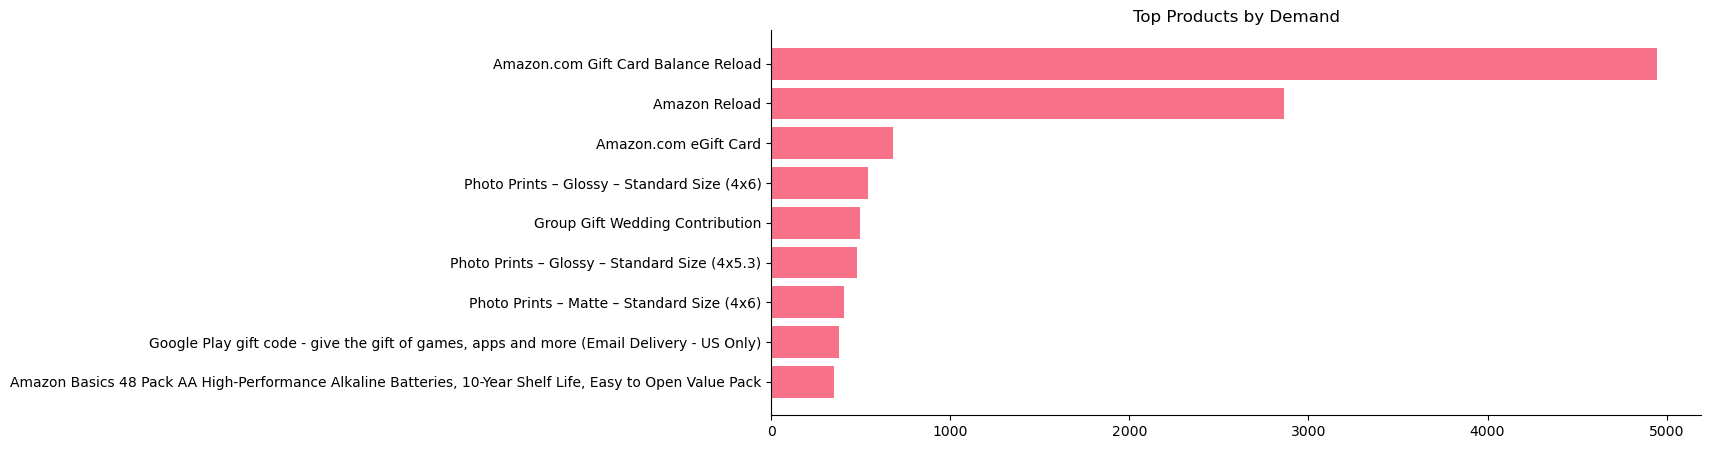

In [39]:
top_products = product_perf.head(10)

plt.figure(figsize=(12,5))
plt.barh(top_products["Title"], top_products["Quantity"])
plt.gca().invert_yaxis()
plt.title("Top Products by Demand")
plt.show()

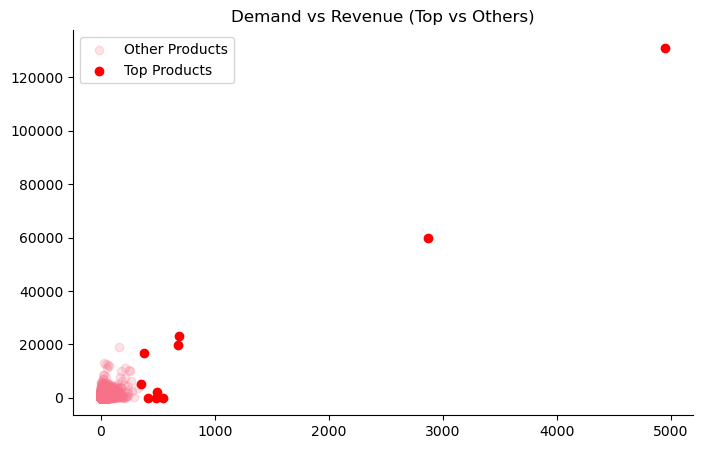

In [40]:
top = product_perf.head(10)
rest = product_perf.iloc[10:]

plt.figure(figsize=(8,5))

plt.scatter(rest["Quantity"], rest["Revenue"], alpha=0.2, label="Other Products")
plt.scatter(top["Quantity"], top["Revenue"], color="red", label="Top Products")

plt.legend()
plt.title("Demand vs Revenue (Top vs Others)")
plt.show()

In [41]:
cat_qty = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

cat_qty.head(10)

Category
Grocery & Food               188870
Home & Kitchen               184698
Clothing & Apparel           111732
Electronics & Accessories    108752
Beauty & Grooming             86637
Books & Media                 69800
Health & Personal Care        61395
Pet Supplies                  54971
Auto & Tools                  47196
Toys & Games                  44447
Name: Quantity, dtype: int64

In [42]:
cat_rev = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

cat_rev.head(10)

Category
Home & Kitchen               4809677.98
Electronics & Accessories    4248358.01
Clothing & Apparel           2666428.53
Grocery & Food               2213410.93
Books & Media                1363326.48
Beauty & Grooming            1252902.18
Auto & Tools                 1130566.89
Health & Personal Care       1097569.81
Pet Supplies                 1024400.43
Toys & Games                  903544.97
Name: Revenue, dtype: float64

In [43]:
top_per_category = (
    df.sort_values(["Category", "Quantity"], ascending=[True, False])
)

top_check = top_per_category.groupby("Category").head(1)[
    ["ASIN/ISBN (Product Code)", "Title", "Raw_Category", "Category", "Quantity", "Revenue"]
].rename(columns={
    "Raw_Category": "raw_category",
    "Category": "mapped_category"
})

top_check

,ASIN/ISBN (Product Code),Title,raw_category,mapped_category,Quantity,Revenue
879316,B01LZZMO9R,Richelieu Hardware BP527320195 Avellino Collec...,HARDWARE_HANDLE,Auto & Tools,32,318.08
317529,B01KX3WJR0,"Maruchan Instant Lunch, Shrimp, 2.25 oz",MEAL_HOLDER,Baby & Maternity,9,3.51
424894,B003CYKDDA,Avalon Organics Intense Defense Oil-Free Moist...,SKIN_MOISTURIZER,Beauty & Grooming,27,306.45
54380,91816971,Who Moved My Cheese? : An Amazing Way to Deal ...,ABIS_BOOK,Books & Media,40,285.20
958534,B09FF5Z6BK,CICIMELON Pop up Pencil Case Cute Telescopic P...,CARRIER_BAG_CASE,Clothing & Apparel,16,66.88
148623,B079H6PDCK,Kingston Canvas Select 16GB microSDHC Class 10...,FLASH_MEMORY,Electronics & Accessories,20,70.80
745228,B0773DQ3YN,Amazon.com Gift Card in a Greeting Card (Vario...,ABIS_GIFT_CARD,Gift Cards,64,1600.00
731597,B006LGHOMO,"Top Ramen Beef Flavor Noodles, 3 oz",NOODLE,Grocery & Food,48,18.72
266432,B00GHNJ1HC,"EO Products Hand Sanitizer Spray for Everyone,...",HAND_SANITIZER,Health & Personal Care,31,61.07
210551,B079NF2NFW,Photo Prints – Glossy – Standard Size (4x5.3),WALL_ART,Home & Kitchen,219,26.28


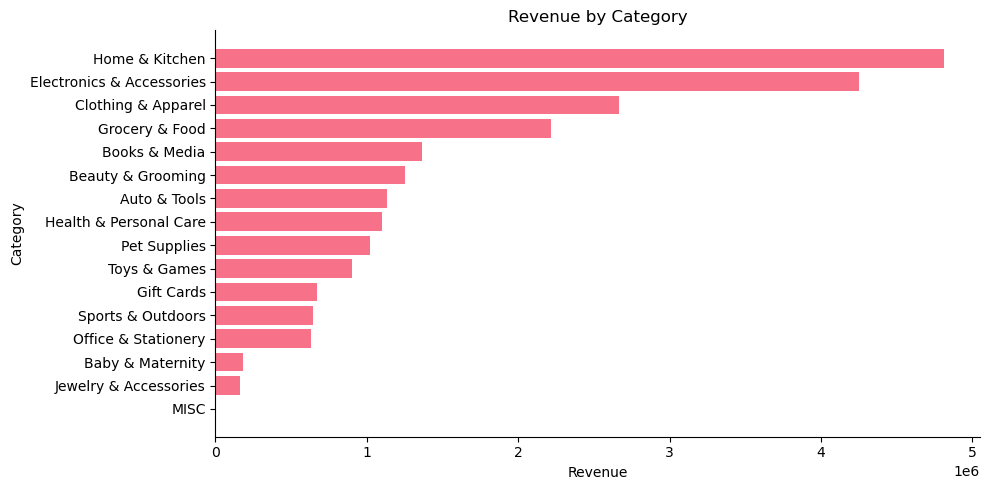

In [44]:

cat_rev = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values()
)

# Plot
plt.figure(figsize=(10,5))
plt.barh(cat_rev.index, cat_rev.values)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

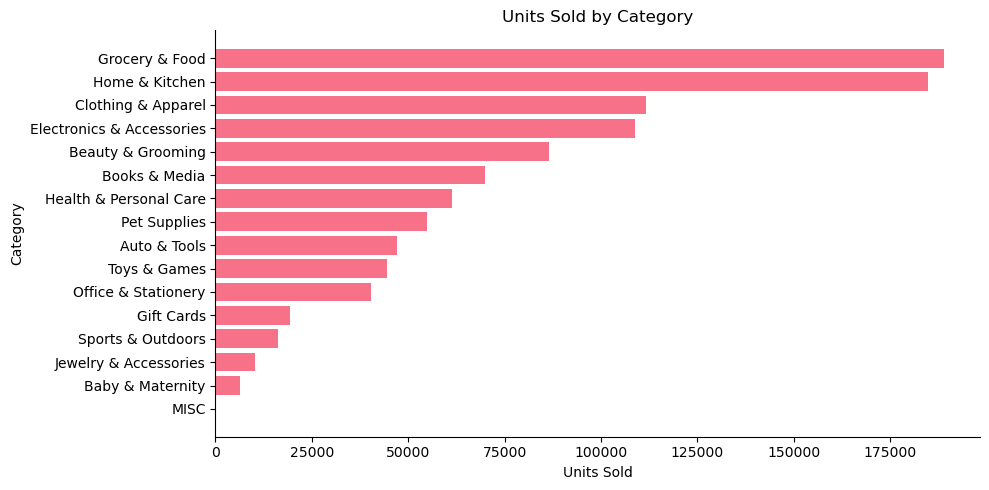

In [45]:
cat_qty = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values()
)

# Plot
plt.figure(figsize=(10,5))
plt.barh(cat_qty.index, cat_qty.values)

plt.title("Units Sold by Category")
plt.xlabel("Units Sold")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

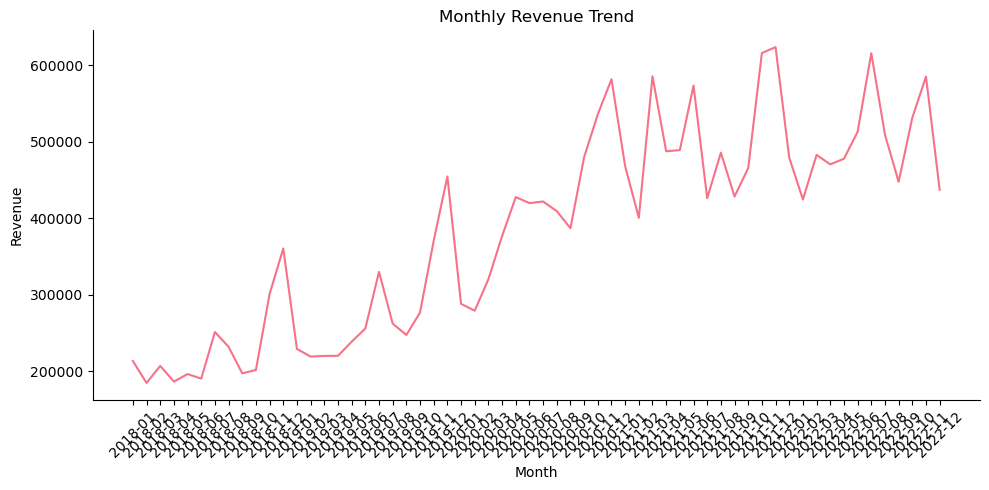

In [46]:

monthly = (
    df.groupby("year_month")["Revenue"]
    .sum()
    .reset_index()
)

# Convert to datetime for proper sorting
monthly["year_month"] = monthly["year_month"].astype(str)
monthly = monthly.sort_values("year_month")

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly["year_month"], monthly["Revenue"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

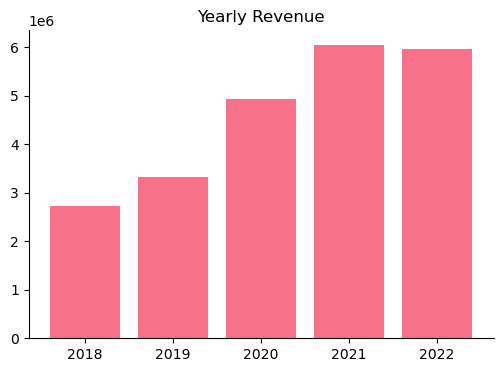

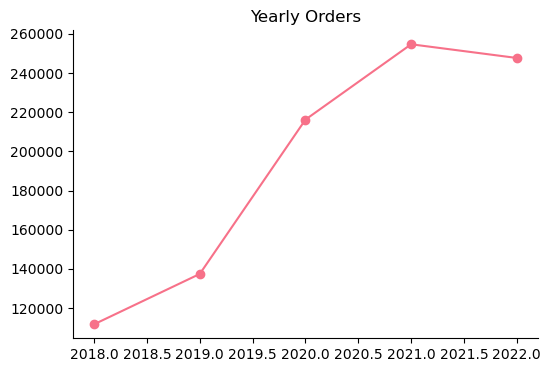

In [47]:

yearly = (
    df.groupby("year")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Quantity", "size")
    )
    .reset_index()
)

# Revenue
plt.figure(figsize=(6,4))
plt.bar(yearly["year"], yearly["Revenue"])
plt.title("Yearly Revenue")
plt.show()

# Orders
plt.figure(figsize=(6,4))
plt.plot(yearly["year"], yearly["Orders"], marker="o")
plt.title("Yearly Orders")
plt.show()

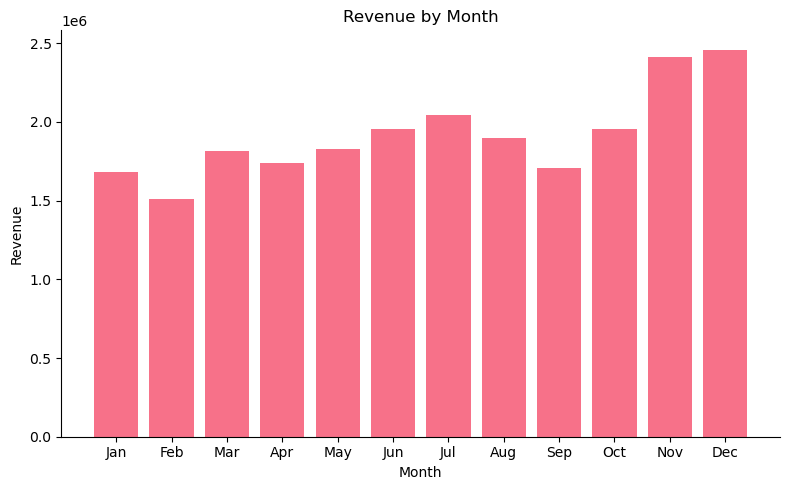

In [48]:


month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_rev = (
    df.groupby("month_name")["Revenue"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(8,5))
plt.bar(monthly_rev.index, monthly_rev.values)

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

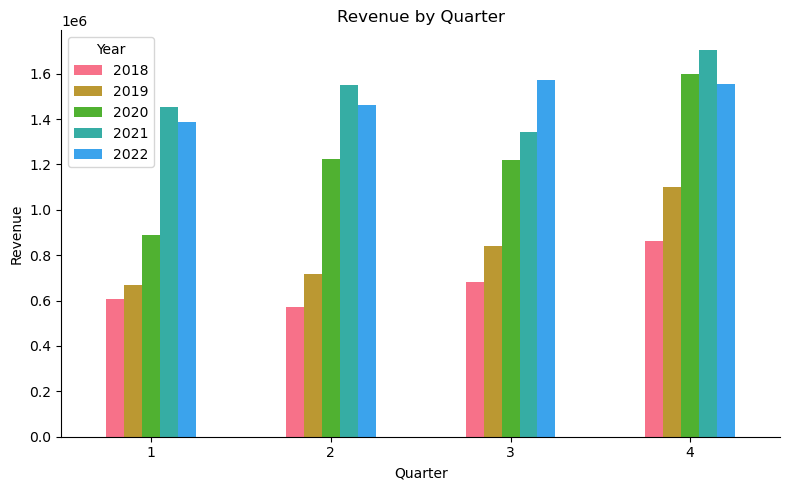

In [49]:
# Revenue by quarter and year
q_data = df.groupby(["quarter", "year"])["Revenue"].sum().unstack()

# Plot
q_data.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.xticks(rotation=0)
plt.legend(title="Year")

plt.tight_layout()
plt.show()

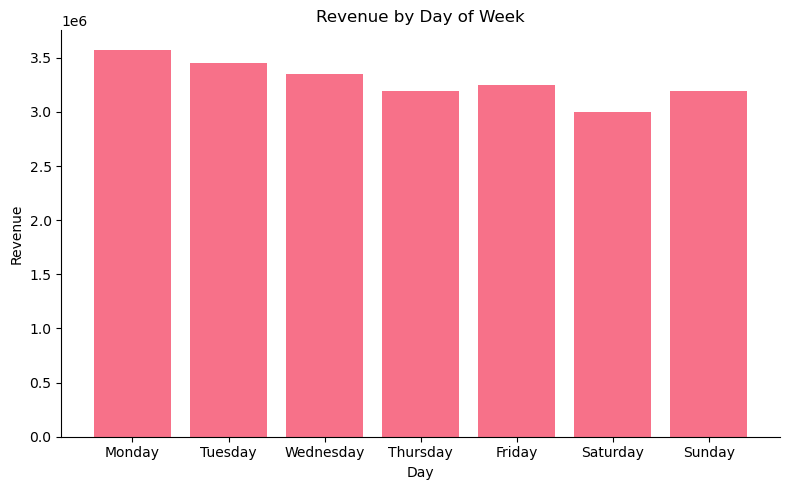

In [50]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dow = (
    df.groupby("day_of_week")["Revenue"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(8,5))
plt.bar(dow.index, dow.values)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

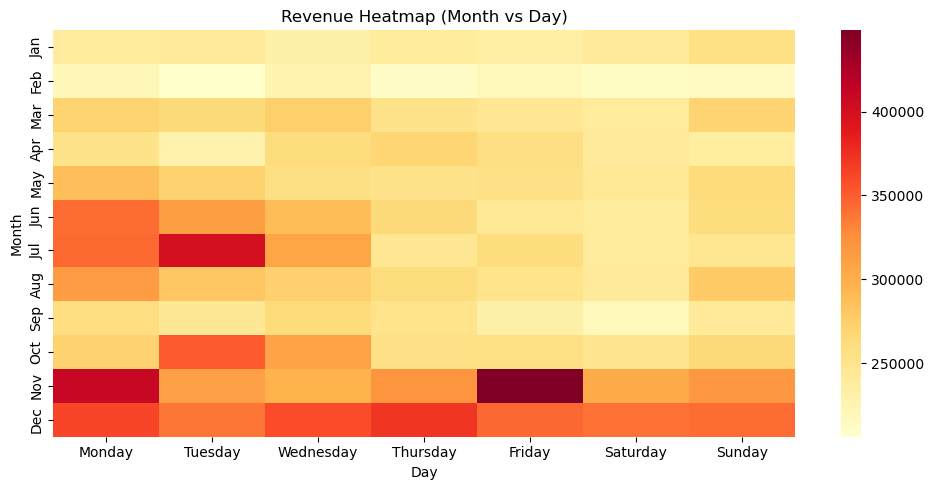

In [51]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

heat = (
    df.groupby(["month_name","day_of_week"])["Revenue"]
    .sum()
    .unstack()
    .reindex(month_order)[day_order]
)

plt.figure(figsize=(10,5))
sns.heatmap(heat, cmap="YlOrRd")

plt.title("Revenue Heatmap (Month vs Day)")
plt.xlabel("Day")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

---
 
## Exploratory Data Analysis (EDA)
 
---
 
## Dataset Snapshot
 
Before diving into individual analyses, here is a single-glance summary of the cleaned dataset.
 
| Metric | Value |
|---|---|
| **Total Orders (Transactions)** | 967,702 |
| **Total Units Sold** | 1,051,128 |
| **Total Revenue** | $23,008,054 |
| **Unique Products (ASINs)** | 546,883 |
| **Business Categories** | 16 |
| **Date Range** | Jan 2018 – Dec 2022 (5 complete years) |
| **Average Order Value** | $23.78 |
| **Median Order Value** | $14.59 |
| **Price Range** | $0.01 – $5,949.00 |
 
---
 
## Category Demand Ranking — Product Prioritisation
 
**Business question:** Which categories should receive the most inventory investment? Which are underperforming?
 
This is ranked by **Total Revenue** — the primary business KPI — with units sold and average order value shown for context.
 
| Rank | Category | Orders | Units Sold | Total Revenue | Revenue Share | Avg Order Value |
|---|---|---|---|---|---|---|
| 🥇 1 | **Home & Kitchen** | 155,314 | 169,180 | **$4,532,811** | 19.7% | $29.18 |
| 🥈 2 | **Electronics & Accessories** | 98,634 | 103,096 | **$4,127,549** | 17.9% | $41.85 |
| 🥉 3 | **Clothing & Apparel** | 103,473 | 106,832 | $2,549,732 | 11.1% | $24.64 |
| 4 | Grocery & Food | 170,999 | 204,693 | $2,432,705 | 10.6% | $14.23 |
| 5 | Books & Media | 71,032 | 73,094 | $1,414,362 | 6.1% | $19.91 |
| 6 | Auto & Tools | 43,174 | 47,590 | $1,177,552 | 5.1% | $27.27 |
| 7 | Beauty & Grooming | 78,229 | 82,382 | $1,143,232 | 5.0% | $14.61 |
| 8 | Health & Personal Care | 55,381 | 60,401 | $1,083,562 | 4.7% | $19.57 |
| 9 | MISC | 38,465 | 41,210 | $880,863 | 3.8% | $22.90 |
| 10 | Sports & Outdoors | 21,316 | 22,847 | $794,357 | 3.5% | $37.27 |
| 11 | Toys & Games | 33,224 | 34,704 | $758,140 | 3.3% | $22.82 |
| 12 | Gift Cards & Services | 17,556 | 18,343 | $602,906 | 2.6% | $34.34 |
| 13 | Pet Supplies | 28,584 | 30,934 | $593,168 | 2.6% | $20.75 |
| 14 | Office & Stationery | 34,080 | 36,926 | $533,215 | 2.3% | $15.65 |
| 15 | Jewelry & Accessories | 13,324 | 13,671 | $223,718 | 1.0% | $16.79 |
| 🔴 16 | **Baby & Maternity** | 4,917 | 5,225 | $160,181 | 0.7% | $32.58 |
 
**Key observations:**
 
- **Home & Kitchen and Electronics together account for 37.6% of all revenue** ($8.66M of $23.0M) — these two categories are the business backbone and must never face stock-outs.
- **Electronics has the highest average order value at $41.85** — customers spend the most per transaction here. Even modest order count growth delivers significant revenue uplift.
- **Grocery & Food is the #1 category by order volume (170,999 orders, 204,693 units)** yet ranks only 4th in revenue. The low average order value of $14.23 means it is a high-frequency, low-margin segment — replenishment speed matters more than premium pricing.
- **Sports & Outdoors is an underrated revenue generator.** It ranks 10th by orders but its $37.27 average order value is the second-highest among all categories. This is a low-traffic, high-basket-size segment — with targeted investment it could punch significantly above its current weight.
- **Baby & Maternity (rank 16) is the weakest segment on every metric** — 0.7% revenue share, 5,225 units over 5 years, fewer than 1,000 orders per year on average.
---
 
## Revenue Growth Year-over-Year
 
**Business question:** Is the business growing? How fast, and what drove the changes?
 
| Year | Total Revenue | Orders | Units Sold | YoY Revenue Growth |
|---|---|---|---|---|
| 2018 | $2,723,671 | 111,757 | 120,166 | — (baseline) |
| 2019 | $3,326,339 | 137,454 | 148,600 | **+22.1%** |
| 2020 | $4,929,400 | 216,201 | 236,445 | **+48.2% ← COVID spike** |
| 2021 | $6,051,972 | 254,639 | 276,605 | **+22.8%** |
| 2022 | $5,976,672 | 247,651 | 269,312 | **−1.2%** |
 
**Key observations:**
 
- **Revenue grew 2.19× from 2018 to 2021** — from $2.72M to $6.05M — a strong compound growth trajectory.
- **2020 was the single biggest jump at +48.2%.** This is directly attributable to COVID-19 lockdowns driving consumers to online shopping. Both orders (+57.7%) and units sold (+59.2%) nearly doubled versus 2019.
- **2021 sustained the momentum (+22.8%)**, confirming the COVID-era shift to e-commerce was not temporary — consumer habits had changed.
- **2022 saw a marginal decline of −1.2% in revenue and −2.7% in orders.** First contraction in the dataset. It signals market maturation — the post-COVID growth surge has absorbed, and growth must now come from operational excellence rather than macro tailwinds.
- Total revenue across all 5 years is **$23.01M**, with 2021 being the peak year at $6.05M.
> **Business implication:** The post-2021 plateau is a critical signal. Growth strategies must shift from riding volume increases to improving category mix, average order value, and retention.
 
---
 
## Monthly Seasonality
 
**Business question:** Which months see the highest demand, and how should inventory be planned around seasonal peaks?
 
| Month | Total Revenue | Orders | Pattern |
|---|---|---|---|
| January | $1,678,690 | 73,172 | Post-holiday dip |
| **February** | **$1,508,888** | **64,893** | **Lowest month of the year** |
| March | $1,816,473 | 76,628 | Recovery begins |
| April | $1,742,110 | 74,845 | Moderate |
| May | $1,830,403 | 77,053 | Stable |
| June | $1,953,335 | 79,434 | Mid-year build |
| July | $2,045,768 | 82,352 | Summer peak (Prime Day) |
| August | $1,899,383 | 82,693 | Post-Prime Day dip |
| September | $1,708,569 | 76,217 | Pre-holiday lull |
| October | $1,956,040 | 82,924 | Holiday ramp-up |
| November | $2,409,565 | 95,207 | Holiday surge |
| **December** | **$2,458,830** | **102,284** | **Peak month of the year** |
 
**Key observations:**
 
- **December ($2.46M) and November ($2.41M) are the two strongest months** — driven by holiday gifting, Black Friday, and year-end purchases. Together they account for **21.2% of annual revenue** despite being just 2 of 12 months.
- **February is the weakest month ($1.51M)** — the deepest point of the post-holiday spending hangover. Revenue in February is 38.8% lower than December.
- **July shows a clear mid-year secondary peak ($2.05M)** — strongly consistent with Amazon Prime Day, which typically falls in July.
- **September is a lull month ($1.71M)** — sandwiched between the summer peak and Q4 ramp. A window for inventory positioning and clearance.
> **Business implication:** Stock build-up must begin in September–October ahead of the Q4 surge. February is the optimal window for clearance, markdowns, and restocking for Q2.
 
---
 
## Quarterly Revenue Pattern
 
**Business question:** Is Q4 dominance consistent across all years, or was it a one-time effect?
 
| Year | Q1 | Q2 | Q3 | **Q4** |
|---|---|---|---|---|
| 2018 | $605,527 | $573,596 | $680,862 | **$863,686** |
| 2019 | $668,687 | $715,123 | $840,035 | **$1,102,493** |
| 2020 | $887,997 | $1,224,630 | $1,218,738 | **$1,598,035** |
| 2021 | $1,454,705 | $1,550,661 | $1,340,823 | **$1,705,782** |
| 2022 | $1,387,134 | $1,461,838 | $1,573,262 | $1,554,439 |
 
**Key observations:**
 
- **Q4 is the strongest quarter in every single year from 2018 to 2021.** This is a structural pattern driven by holiday shopping, not a coincidence.
- **Q4 accounts for 29.7% of total 5-year revenue** ($6.83M of $23.0M) — nearly a third of all revenue lands in the final three months of the year.
- **2020 Q2 was unusually high ($1.22M)** — matching Q3 — because COVID lockdowns hit during April–June, creating a mid-year demand spike not present in other years.
- **2022 breaks the Q4-dominance pattern** — Q3 ($1.57M) slightly exceeded Q4 ($1.55M). This may indicate early seasonal purchasing, shifting promotional calendars, or demand flattening.
- **Q1 is the weakest quarter every year**, consistent with the February dip observed in monthly analysis.
> **Business implication:** Q4 is non-negotiable for inventory preparation. Any supply chain disruption between August and October directly risks the highest-value revenue window of the year.
 
---
 
## Day-of-Week Purchasing Behaviour
 
**Business question:** Which days generate the most revenue? When should promotions and campaigns launch?
 
| Day | Total Revenue | Orders | Revenue Index (Mon = 100) |
|---|---|---|---|
| **Monday** | **$3,574,929** | **146,916** | **100** |
| Tuesday | $3,452,746 | 142,700 | 96.6 |
| Wednesday | $3,346,614 | 140,248 | 93.6 |
| Thursday | $3,192,525 | 134,513 | 89.3 |
| Friday | $3,245,477 | 135,102 | 90.8 |
| Saturday | $3,003,574 | 129,709 | 84.0 |
| **Sunday** | $3,192,189 | 138,514 | 89.3 |
 
**Key observations:**
 
- **Monday is the single highest revenue day at $3.57M** — customers appear to translate weekend browsing decisions into Monday purchases.
- **Revenue declines progressively from Monday to Saturday**, with a slight Friday and Sunday recovery.
- **Saturday is the lowest revenue day ($3.00M)** — $571K below Monday, representing a 16% gap.
- All weekdays (Mon–Fri) outperform both weekend days.
> **Business implication:** Email campaigns, flash sales, and new product launches should be timed for **Monday or Tuesday** to maximise reach during peak buying intent. Weekend-only promotions will underperform relative to weekday equivalents.
 
---
 
## Top 15 Products by Demand
 
**Business question:** Which specific products drive the most unit volume? *(Gift cards excluded as they are financial instruments, not merchandise.)*
 
| Rank | Product | Category | Units Sold | Revenue |
|---|---|---|---|---|
| 1 | Photo Prints – Glossy – Standard Size (4×6) | Home & Kitchen | 540 | $75 |
| 2 | Photo Prints – Glossy – Standard Size (4×5.3) | Home & Kitchen | 479 | $62 |
| 3 | Photo Prints – Matte – Standard Size (4×6) | Home & Kitchen | 409 | $61 |
| 4 | Amazon Basics 48-Pack AA Alkaline Batteries | Electronics & Accessories | 351 | $5,133 |
| 5 | Amazon Basics 36-Pack AAA Alkaline Batteries | Electronics & Accessories | 324 | $3,542 |
| 6 | Cucumber (Slicing) | Grocery & Food | 285 | $207 |
| 7 | $10 Xbox Gift Card [Digital Code] | Books & Media | 273 | $2,722 |
| 8 | Echo Dot (3rd Gen, 2018) – Smart Speaker with Alexa | Electronics & Accessories | 265 | $6,142 |
| 9 | Fire TV Stick 4K with Alexa Voice Remote | Electronics & Accessories | 246 | $10,264 |
| 10 | Equal 0-Calorie Sweetener Tablets | Grocery & Food | 240 | $481 |
| 11 | Purina Friskies Gravy Wet Cat Food Variety Pack | Grocery & Food | 237 | $2,843 |
| 12 | Hills Bros Instant White Chocolate Caramel Cappuccino | Grocery & Food | 224 | $692 |
| 13 | Yellow Onion | Grocery & Food | 221 | $159 |
| 14 | Dr. Elsey's Premium Clumping Cat Litter – Ultra | MISC | 214 | $4,025 |
| 15 | Maruchan Ramen Noodle Soup, Creamy Chicken (3 oz) | Grocery & Food | 207 | $58 |
 
**Key observations:**
 
- **Photo Prints dominate by raw unit count** (ranks 1–3) but generate almost no revenue — $75, $62, and $61 respectively. These are high-frequency micro-purchases with negligible revenue impact.
- **Amazon Basics Batteries (ranks 4 and 5) are the highest true merchandise performers** — 675 combined units and $8,675 combined revenue. A consumable with strong repeat-purchase behaviour.
- **Amazon's own devices appear in the top 10.** Echo Dot (265 units, $6,142) and Fire TV Stick 4K (246 units, $10,264) both confirm that Amazon's hardware ecosystem drives significant volume.
- **5 of the top 15 products are Grocery & Food items**, but most generate very low revenue per unit — cucumbers (~$0.73 each), onions (~$0.72 each), ramen (~$0.28 each).
- **Fire TV Stick 4K generates the highest revenue of any single product** in the top-15 at $10,264 — with only 246 units, its ~$41.72 per unit drives outsized revenue impact.
> **Business implication:** Unit volume and revenue are not correlated at the product level. Prioritise stocking products with **both** high unit velocity **and** meaningful revenue per unit — Amazon Basics Batteries and Amazon devices are the clearest examples here.
 
---
 
## EDA Summary & Business Insights
 
The following table consolidates the key findings from all analyses above into actionable business recommendations.
 
| # | Finding | Business Action |
|---|---|---|
| 1 | Home & Kitchen and Electronics drive **37.6% of all revenue** combined | Never allow stock-outs in these two categories — they are the revenue backbone |
| 2 | Electronics has the **highest average order value at $41.85** | Upsell and cross-sell within Electronics to increase basket size |
| 3 | Grocery & Food has the **most orders (170,999) but the lowest avg value ($14.23)** | Optimise for replenishment speed and low fulfilment cost; margin management is critical |
| 4 | **Q4 = 29.7% of annual revenue** — strongest every year without exception | Build inventory buffer by October; Q4 stock-outs are catastrophically expensive |
| 5 | **December + November = 21.2% of annual revenue** | Plan campaigns and stock peaks for Black Friday and Christmas |
| 6 | **February is the lowest revenue month** ($1.51M vs $2.46M in December) | Use February for clearance, restocking, and supplier negotiations |
| 7 | **Monday is the highest revenue day** — 16% above Saturday | Launch campaigns and email sends on Monday/Tuesday for maximum conversion |
| 8 | **2020 showed +48.2% revenue growth** driven by COVID — now stabilising | Do not model future growth on 2020 — use 2019 and 2022 as the realistic baseline references |
| 9 | **Revenue declined −1.2% in 2022** — first contraction in 5 years | Investigate category-level trends; Home/Electronics may be showing early saturation |
| 10 | **Sports & Outdoors: $37.27 avg order value** but only 2.2% order share | High-potential underserved category — targeted marketing could unlock significant revenue |
| 11 | **Baby & Maternity: 0.7% revenue share** over 5 years | Either invest in category development or redirect resources to higher-performing segments |
 
---

## 5. Demand Forecasting & Sales Modeling

In this section, we transition from looking at past data to predicting future demand for the Home & Kitchen category using simple forecasting methods to help optimize inventory decisions because our initial data exploration proved it is the MVP (Most Valuable Product) of the business. Since this single department drives the vast majority of our overall revenue, it carries the highest financial risk if we run out of stock. By predicting future demand for our most profitable items first, we ensure that our biggest money-maker always has exactly enough inventory to meet customer needs without overspending on excess warehouse space

*Step 1: Data Filtering*

In [66]:

df_hk = df[df["Category"] == "Home & Kitchen"]

In [65]:
df_hk.head() 

,Order Date,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Raw_Category,Revenue,Category,year,month,month_name,quarter,week_of_year,day_of_week,year_month
6,2018-01-01,139.00,1,"Need Computer Desk, 55 inches Large Office Des...",B01N3PU180,DESK,139.00,Home & Kitchen,2018,1,Jan,1,1,Monday,2018-01
11,2018-01-01,15.99,1,Lawrence Frames,B017INB3HU,PICTURE_FRAME,15.99,Home & Kitchen,2018,1,Jan,1,1,Monday,2018-01
23,2018-01-01,86.84,1,EdgeMod Manchester Office Chair in Vegan Leath...,B06XFXY516,CHAIR,86.84,Home & Kitchen,2018,1,Jan,1,1,Monday,2018-01
26,2018-01-01,17.98,1,"Weddingstar (7073-56) Polished Flask, Rose Gold",B01H3Z0LD0,HIP_FLASK,17.98,Home & Kitchen,2018,1,Jan,1,1,Monday,2018-01
29,2018-01-01,32.28,1,Serta Gel Memory Foam Side Sleeper Pillow,B010AIOH9G,PILLOW,32.28,Home & Kitchen,2018,1,Jan,1,1,Monday,2018-01


In [54]:
df_hk.shape

(169269, 15)

*Step 2: Data Aggregation*

In [55]:
# Grouping the sales by month to see the trend 
monthly_hk = df_hk.groupby("year_month")["Revenue"].sum().reset_index()

monthly_hk.head()

,year_month,Revenue
0,2018-01,40771.02
1,2018-02,36575.28
2,2018-03,36807.93
3,2018-04,36913.94
4,2018-05,37687.62


In [56]:
monthly_hk.shape

(60, 2)

*Step 3: Plot the Monthly Revenue Trend for Home & Kitchen*

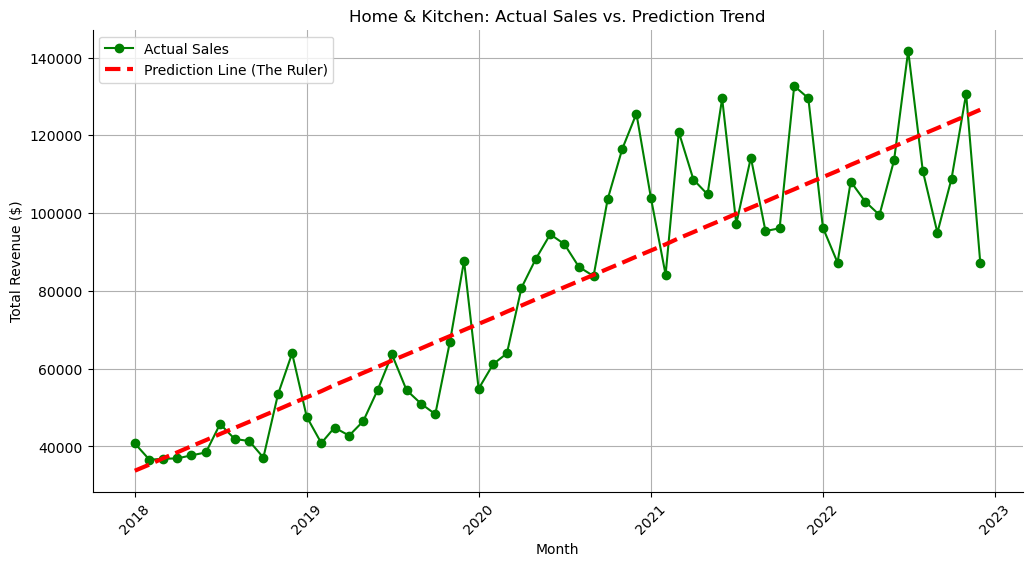

In [68]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. This creates a simple count: Month 0, Month 1, Month 2... up to 59
monthly_hk['Time'] = np.arange(len(monthly_hk))

# 2. Set up X (Time) and Y (Money)
X = monthly_hk[['Time']]   
Y = monthly_hk['Revenue']  

# 3. Create and Train the Model (Laying the ruler down)
model = LinearRegression()
model.fit(X, Y)

# 4. Asking computer to draw the "Best Fit" line
predicted_revenue = model.predict(X)

# 5. Plot the old dots AND the new Prediction Ruler together
plt.figure(figsize=(12, 6))
plt.plot(monthly_hk['year_month'], Y, marker='o', color='green', label='Actual Sales')
plt.plot(monthly_hk['year_month'], predicted_revenue, color='red', linestyle='--', linewidth=3, label='Prediction Line (The Ruler)')

plt.title('Home & Kitchen: Actual Sales vs. Prediction Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

This chart shows the five-year 'heartbeat' of our Home & Kitchen department. The green dots show exactly what happened in real life every month—you can see those huge spikes every winter when people do their holiday shopping. But because that green line is so jumpy, we used a machine-learning tool to calculate a 'best-fit' trend line, which is the dashed red line cutting straight through the middle. That red line is the most important part of the whole project because it proves that, despite the messy ups and downs of the seasons, our overall sales are steadily climbing higher every single year. It tells us the business is healthy and we need to order more inventory to prepare for next year.

*Step 4: Evaluation (The Trust Score Model Evaluation)*

In [62]:
from sklearn.metrics import mean_absolute_error, r2_score 

#1. Model predicting the past (60 months we already know) 
past_predictions = model.predict(X) 

#2. Comparing the model's guesses to the Actual past sales (Y) 
error_dollars = mean_absolute_error(Y, past_predictions) 
accuracy_score = r2_score(Y, past_predictions)

#3. Printing the final report card
print("--- MODEL TRUST SCORE ---") 
print(f"Accuracy Grade (R-squared): {accuracy_score * 100:.1f}%") 
print(f"Average Margin of Error: ${error_dollars:,.2f}")


--- MODEL TRUST SCORE ---
Accuracy Grade (R-squared): 76.6%
Average Margin of Error: $11,973.90


Our model has a 76.6% accuracy grade, which is quite high for this kind of retail data. It shows a strong upward trend, though we should keep in mind that the model's predictions usually have a $12,000 buffer zone due to the seasonal spikes we see every year.

*Step 5: Forecasting*

In [63]:
import pandas as pd

# 1. Creating a list of the next 12 months (Months 60 through 71)
future_months = pd.DataFrame({'Time': [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]})

# 2. Asking the model to predict all 12 months at once
full_year_prediction = model.predict(future_months)

# 3. Printing a 2023 Playbook
print("--- 2023 INVENTORY PURCHASING FORECAST ---")
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i in range(12):
    print(f"{months[i]} 2023: ${full_year_prediction[i]:,.2f}")

--- 2023 INVENTORY PURCHASING FORECAST ---
Jan 2023: $128,153.75
Feb 2023: $129,727.27
Mar 2023: $131,300.79
Apr 2023: $132,874.32
May 2023: $134,447.84
Jun 2023: $136,021.36
Jul 2023: $137,594.89
Aug 2023: $139,168.41
Sep 2023: $140,741.93
Oct 2023: $142,315.46
Nov 2023: $143,888.98
Dec 2023: $145,462.50


For the final step of this, we needed to turn our mathematical model into a real-world business tool. Since we already proved our model is accurate, we asked it to look past our historical data and predict the next 12 months in a row. The result is a complete 2023 Inventory Playbook. As you can see, the model projects our baseline sales will climb from 128,000 in January to over $145,000 by December. This gives the purchasing team exactly what they need to order the right amount of stock ahead of time, ensuring we never leave money on the table.